# Notebook 03 — Production Pipeline: Train, Track, Register, Serve

**Module:** ITI113 Machine Learning & Operations
**Focus Area:** C — MLOps (Production pipeline, experiment tracking, registry, deployment, CI/CD)
**Project:** Airbnb *fair advertised nightly rate* — **regression** on the continuous nightly `price` (this notebook stays strictly inside that scope: no classification heads, no invented tasks)
**Estimated Runtime:** ~8–12 minutes locally; 15–25 minutes for a full SageMaker Pipeline execution

---

## What this notebook does

1. Consolidates Notebook 01's exploratory preprocessing into **one reusable scikit-learn Pipeline module** (`src/pipeline_lib.py`) — the single source of truth imported by this notebook, the SageMaker jobs, *and* the inference endpoint.
2. Writes the three job scripts (`preprocess.py`, `train.py`, `inference.py`) and **executes them end-to-end** (locally as subprocesses; on SageMaker as managed Processing/Training jobs).
3. **Proves train–serve consistency byte-for-byte**: the serialized pipeline's fitted state and output matrix are asserted equal to Notebook 01's artifacts, and its test metrics equal to Notebook 02's champion run.
4. Logs the production training run to the team **MLflow tracking server** — parameters, metrics, **data versions**, and the serialized pipeline artifact — after validating the MLflow App `TeamId` tag.
5. **Registers the champion** in the Model Registry with version, lineage and an approval status, and demonstrates the *only-approved-versions-deploy* rule in code.
6. Defines the parameterized **SageMaker Pipeline** (Process → Train → Quality Gate → Register) and the **Serverless Inference** deployment path, with a local smoke test of the exact serving contract.
7. Explains, in engineering-grade Markdown, how **CI/CD, deployment automation, and monitoring dashboards** wrap around this code in the final production state.

## How this maps to the target architecture

| Architecture layer | Where it lives here | Implementation |
|---|---|---|
| **Data — S3, one project bucket** | Step 0, Step 3 | `…/raw/` (immutable `Listings.csv`), `…/processed/` (versioned cleaned splits + manifest), `…/artifacts/` (serialized pipeline, evaluation report, manifest). Bucket assumed SSE-encrypted; the team execution role is scoped to the team prefix (least privilege) and to MLflow Apps tagged `TeamId=team14`. |
| **Development & preprocessing — SageMaker Studio** | Step 1–Step 4 | Encoders are *fitted* inside the pipeline and the **fitted pipeline is serialized to `/artifacts`** — the train-serve-consistency guarantee, proven in Step 4. |
| **Training — SageMaker Training Jobs** | Step 3 (local run), Step 7 (managed run) | `train.py` is fully **parameterized** (champion hyperparameters overridable per execution), reads `/processed`, writes `/artifacts`. |
| **Experiment tracking — MLflow on SageMaker** | Step 0A, Step 5, Step 7.3 | Every run logs params, metrics, **data versions** and artifacts to the team MLflow App (tag-checked); local fallback is the SQLite store from Notebook 02. |
| **Model registry — MLflow / SageMaker** | Step 6, Step 7 | Champion registered with **version + lineage + approval status**; deployment helper refuses anything not `approved`. On AWS, the pipeline's `ModelStep` registers into SageMaker Model Registry as `PendingManualApproval`. |
| **Serving — SageMaker Serverless Inference** | Step 8 | Approved model → serverless endpoint (`memory=3072`, `max_concurrency=5`): **scale-to-zero for intermittent, bursty demo traffic**, paying per-invocation instead of per-hour. |

```text
SageMaker Pipeline                          Notebook-side MLflow logging
Process → Train → Gate → Register           Read job metadata → log to team MLflow App
(no MLflow creds inside containers)         (tag-checked, presigned UI links)
```


> **Prerequisites:** Notebook 01 artifacts (`processed/` + `preprocessing_artifacts.json`), Notebook 02's `best_model.json` and MLflow experiment, Notebook 01A's MLflow App config JSON (SageMaker mode). Off SageMaker everything runs in **LOCAL_MODE** against the same code paths.

## Install or update required packages *(SageMaker Studio only)*

Uncomment on Studio and restart the kernel after installing. Locally, Notebook 02 already established the MLflow SQLite store.

In [1]:
# %pip install --upgrade "sagemaker>=2,<3" boto3 botocore
# %pip install --upgrade mlflow sagemaker-mlflow
# %pip install "shap>=0.45"

## 0. Configuration

Same team constants as Notebooks 01/02, plus the production naming: the **three S3 prefixes** of the data layer, the pipeline / model-package-group / endpoint names, and the quality gate carried over from Notebook 02. The champion hyperparameters are **not hard-coded**: they are pulled from the Notebook 02 MLflow run recorded in `best_model.json` — the first link in the lineage chain this notebook maintains end-to-end.

In [2]:
import os, io, sys, json, glob, time, hashlib, tempfile, subprocess, warnings, re, contextlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# ============================================================
# Student / team settings — change only these
# ============================================================
TEAM_ID      = "team14"
STUDENT_ID   = "s1402"
COURSE       = "ITI113"
SEMESTER     = "26S1"
PROJECT_NAME = "airbnb-listings"
REGION       = "ap-southeast-1"

BUCKET = "nyp-26s1-iti113"
PREFIX = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"

# --- The data layer: one project bucket, three prefixes (SSE + least-privilege IAM assumed)
RAW_PREFIX       = f"{PREFIX}/raw"          # immutable Listings.csv
PROCESSED_PREFIX = f"{PREFIX}/processed"    # versioned cleaned datasets
ARTIFACTS_PREFIX = f"{PREFIX}/artifacts"    # serialized pipeline, eval outputs, manifests

RANDOM_STATE = 42
TEST_SIZE    = 0.20
QUALITY_GATE_R2LOG = 0.65                   # same gate as Notebook 02

# --- Production object names
PIPELINE_NAME       = f"iti113-{TEAM_ID}-airbnb-price"
MODEL_PACKAGE_GROUP = f"iti113-{TEAM_ID}-airbnb-price-models"     # SageMaker Model Registry
REGISTRY_MODEL_NAME = f"iti113-{TEAM_ID}-airbnb-price-regressor"  # MLflow Model Registry
ENDPOINT_NAME       = f"iti113-{TEAM_ID}-airbnb-price-sls"
PROCESSING_INSTANCE_TYPE = "ml.m5.large"
TRAINING_INSTANCE_TYPE   = "ml.m5.large"

# ============================================================
# Environment detection: SageMaker vs local
# ============================================================
try:
    import sagemaker, boto3
    session = sagemaker.Session()
    role = sagemaker.get_execution_role()
    LOCAL_MODE = False
    print(f"SageMaker mode | role: {role.split('/')[-1]}")
except Exception:
    LOCAL_MODE = True
    print("SageMaker not available -> LOCAL_MODE (scripts run as local subprocesses; "
          "SQLite MLflow store; local artifact folders mirror the S3 prefixes)")

# Local mirrors of the three prefixes
RAW_CANDIDATES  = ["/mnt/user-data/uploads/Listings.csv", "Listings.csv", "data/Listings.csv"]
RAW_LOCAL       = next((p for p in RAW_CANDIDATES if os.path.exists(p)), RAW_CANDIDATES[0])
LOCAL_PROCESSED = "pipeline_processed"      # this notebook's cleaned, versioned splits
LOCAL_ARTIFACTS = "artifacts"               # serialized pipeline + evaluation outputs
NB01_PROCESSED  = "processed"               # Notebook 01's outputs (consistency reference)
os.makedirs(LOCAL_ARTIFACTS, exist_ok=True)

# ============================================================
# MLflow App discovery (config saved by Notebook 01A)
# ============================================================
DEFAULT_MLFLOW_APP_ARN = "arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PIGMOQJH46PS"
config_candidates = ([Path(f"mlflow_app_config_{TEAM_ID}.json"),
                      Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")]
                     + [Path(p) for p in sorted(glob.glob(f"mlflow_app_config_{TEAM_ID}_*.json"))])
MLFLOW_APP_ARN, MLFLOW_CONFIG_SOURCE = None, None
for cand in config_candidates:
    if cand.exists():
        MLFLOW_APP_ARN = json.loads(cand.read_text()).get("MLFLOW_APP_ARN")
        MLFLOW_CONFIG_SOURCE = str(cand); break
if MLFLOW_APP_ARN is None and DEFAULT_MLFLOW_APP_ARN:
    MLFLOW_APP_ARN, MLFLOW_CONFIG_SOURCE = DEFAULT_MLFLOW_APP_ARN, "DEFAULT_MLFLOW_APP_ARN"

MLFLOW_EXPERIMENT = f"{COURSE}/{TEAM_ID}/Experiment1"
if LOCAL_MODE:
    MLFLOW_TRACKING_URI = "sqlite:///mlflow_local.db"      # Notebook 02's local store
    MLFLOW_CONFIG_SOURCE = MLFLOW_CONFIG_SOURCE or "local SQLite store"
else:
    if MLFLOW_APP_ARN is None:
        raise RuntimeError("No MLflow App config found. Run Notebook 01A or set DEFAULT_MLFLOW_APP_ARN.")
    MLFLOW_TRACKING_URI = MLFLOW_APP_ARN

# ============================================================
# Champion lineage: Notebook 02 hand-off
# ============================================================
# Local copy first; then the /artifacts zone, where Notebook 02 SS8A publishes it.
# The local file lives on ephemeral per-space disk -- S3 is what makes this
# hand-off survive a space reset, a teammate, or a CI runner.
if os.path.exists("best_model.json"):
    BEST = json.loads(Path("best_model.json").read_text())
    BEST_SOURCE = "local best_model.json"
elif not LOCAL_MODE:
    _key = f"{PREFIX}/artifacts/best_model.json"
    try:
        BEST = json.loads(boto3.client("s3", region_name=REGION)
                          .get_object(Bucket=BUCKET, Key=_key)["Body"].read())
        Path("best_model.json").write_text(json.dumps(BEST, indent=4))   # cache locally
        BEST_SOURCE = f"s3://{BUCKET}/{_key}"
    except Exception as _e:
        raise FileNotFoundError(
            f"best_model.json found neither locally nor at s3://{BUCKET}/{_key} ({_e}). "
            "Run Notebook 02 through SS8A, which publishes it.") from None
else:
    raise FileNotFoundError("best_model.json not found — run Notebook 02 first.")
print(f"Champion hand-off source: {BEST_SOURCE}")
print(f"\nChampion from Notebook 02: {BEST['best_run_name']}")
print(f"  run_id {BEST['best_run_id']} | test_r2_log {BEST['best_metrics']['test_r2_log']:.4f} "
      f"| gate passed: {BEST['quality_gate']['passed']}")
print(f"Raw data       : {RAW_LOCAL if LOCAL_MODE else f's3://{BUCKET}/{RAW_PREFIX}/Listings.csv'}")
print(f"MLflow config  : {MLFLOW_CONFIG_SOURCE}")
print(f"Tracking URI   : {MLFLOW_TRACKING_URI}")
print(f"Experiment     : {MLFLOW_EXPERIMENT}")
print(f"Pipeline       : {PIPELINE_NAME}")
print(f"Registry       : {REGISTRY_MODEL_NAME} (MLflow) / {MODEL_PACKAGE_GROUP} (SageMaker)")
print(f"Endpoint       : {ENDPOINT_NAME} (serverless)")
# WARNING: This deletes the entire model and all of its versions from the registry!
# client.delete_registered_model(name=REGISTRY_MODEL_NAME)
# print(f"Deleted the entire registered model: {REGISTRY_MODEL_NAME}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


SageMaker mode | role: SageMakerExecutionRole-ITI113-Team14
Champion hand-off source: local best_model.json

Champion from Notebook 02: team14_s1402_champion_refit
  run_id 3799806706b946aa88a316ffaa4eeb6d | test_r2_log 0.8708 | gate passed: True
Raw data       : s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/raw/Listings.csv
MLflow config  : DEFAULT_MLFLOW_APP_ARN
Tracking URI   : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PIGMOQJH46PS
Experiment     : ITI113/team14/Experiment1
Pipeline       : iti113-team14-airbnb-price
Registry       : iti113-team14-airbnb-price-regressor (MLflow) / iti113-team14-airbnb-price-models (SageMaker)
Endpoint       : iti113-team14-airbnb-price-sls (serverless)


## 0A. Connect to MLflow — team-tag safety check and champion hyperparameters

Same guardrail as Notebook 02: the MLflow App's `TeamId` tag must match `TEAM_ID` **before anything is logged** (team-level IAM should 403 a wrong ARN anyway; this check fails earlier and with a clearer message). Then the champion's exact hyperparameters are pulled **from the Notebook 02 MLflow run itself** 

In [3]:
import mlflow
import mlflow.sklearn
import logging
logging.getLogger("mlflow").setLevel(logging.ERROR)
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"

if not LOCAL_MODE:
    sm_client = boto3.client("sagemaker", region_name=REGION)
    tag_response = sm_client.list_tags(ResourceArn=MLFLOW_APP_ARN)
    mlflow_app_tags = {t["Key"]: t["Value"] for t in tag_response.get("Tags", [])}
    app_team_id = mlflow_app_tags.get("TeamId")
    if app_team_id != TEAM_ID:
        raise PermissionError(
            f"MLflow App TeamId tag mismatch. App TeamId={app_team_id}, notebook TEAM_ID={TEAM_ID}. "
            "Do not log to another team's MLflow App.")
    print(f"[OK] MLflow App tag TeamId={app_team_id} matches notebook TEAM_ID={TEAM_ID}")
else:
    print("[SKIP] LOCAL_MODE — no SageMaker App to tag-check; using the local SQLite store.")

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

COMMON_TAGS = {
    "course": COURSE, "semester": SEMESTER, "team_id": TEAM_ID, "student_id": STUDENT_ID,
    "project_name": PROJECT_NAME, "task_type": "regression",
    "tracking_backend": "local_sqlite" if LOCAL_MODE else "sagemaker_mlflow_app",
    "notebook": "03_production_pipeline",
}

# --- Champion hyperparameters from the Notebook 02 hand-off (lineage, not copy-paste)
# Resolution order, most authoritative first:
#   1. best_model.json's `hyperparameters` block  (declared contract, NB02 §8B)
#   2. plain param names on the run               (champion refit)
#   3. `best_*` param names on the run            (legacy tuning-parent hand-off)
HP_KEYS = {"learning_rate": float, "max_leaf_nodes": int, "max_iter": int,
           "min_samples_leaf": int, "l2_regularization": float}

_champion_run = mlflow.get_run(BEST["best_run_id"])
_p = _champion_run.data.params

if isinstance(BEST.get("hyperparameters"), dict) and all(k in BEST["hyperparameters"] for k in HP_KEYS):
    _raw, _source = BEST["hyperparameters"], "best_model.json -> hyperparameters"
elif all(k in _p for k in HP_KEYS):
    _raw, _source = _p, f"run {BEST['best_run_id'][:12]}… params (champion refit)"
elif all(f"best_{k}" in _p for k in HP_KEYS):
    _raw = {k: _p[f"best_{k}"] for k in HP_KEYS}
    _source = f"run {BEST['best_run_id'][:12]}… params (legacy best_* prefix)"
else:
    raise KeyError(
        "Could not resolve champion hyperparameters.\n"
        f"  best_model.json keys : {sorted(BEST)}\n"
        f"  run parameter keys   : {sorted(_p)}\n"
        f"Expected a `hyperparameters` block in best_model.json, or {sorted(HP_KEYS)} "
        "on the run (bare or `best_`-prefixed). Re-run Notebook 02 §8B.")

# Exactly the five knobs train.py accepts. The refit run also carries early_stopping
# and random_state, which build_model_pipeline() sets itself — passing them through
# would collide and would leak into cell 26's hp_* params.
CHAMPION_PARAMS = {k: cast(_raw[k]) for k, cast in HP_KEYS.items()}

# pipeline_lib.build_model_pipeline() hardcodes HistGradientBoostingRegressor, and
# these five knobs are meaningless for anything else. Fail here rather than train an
# HGB using another family's settings.
_family = BEST.get("model_type", "HistGradientBoostingRegressor")
if _family != "HistGradientBoostingRegressor":
    raise RuntimeError(
        f"Notebook 02 selected {_family}, but pipeline_lib.build_model_pipeline() "
        "hardcodes HistGradientBoostingRegressor. Update and re-version pipeline_lib first.")

print(f"MLflow {mlflow.__version__} connected | experiment: {MLFLOW_EXPERIMENT}")
print(f"Champion hyperparameters (resolved from: {_source}):")
for k, v in CHAMPION_PARAMS.items():
    print(f"  {k:18s} = {v}")

_sel = BEST.get("selection")
if _sel:
    print(f"\nSelected in Notebook 02 as '{_sel['selected_run_name']}'")
    print(f"  on {_sel['metric']} = {_sel['value']:.4f}, "
          f"margin over runner-up {_sel.get('runner_up_margin', float('nan')):.4f}")
_proto = BEST.get("validation_protocol")
if _proto:
    _reads = _proto.get("test_decisions", _proto.get("test_set_reads", "n/a"))
    print(f"  protocol: fit {_proto['n_fit']:,} / val {_proto['n_val']:,} / "
          f"test {_proto['n_test']:,}; champion refit on {_proto['n_train_refit']:,}; "
          f"test decisions = {_reads}")

[OK] MLflow App tag TeamId=team14 matches notebook TEAM_ID=team14


MLflow 3.15.1 connected | experiment: ITI113/team14/Experiment1
Champion hyperparameters (resolved from: best_model.json -> hyperparameters):
  learning_rate      = 0.1
  max_leaf_nodes     = 127
  max_iter           = 300
  min_samples_leaf   = 50
  l2_regularization  = 1.0

Selected in Notebook 02 as 'team14_s1402_hgb_tuning_parent'
  on val_mae_log = 0.3262, margin over runner-up 0.0148
  protocol: fit 178,715 / val 44,679 / test 55,849; champion refit on 223,394; test decisions = 1


In [4]:
# ================================================================
# 0B. Presigned MLflow App UI links
# ----------------------------------------------------------------
# MLflow prints generic links like https://mlflow.sagemaker.<region>.app.aws/#/...
# Those are NOT presigned and will show a permission/session error. Generate a
# fresh presigned URL instead and append the UI route as a fragment.
#
# SECURITY: a presigned URL is a CREDENTIAL. Anyone holding it can act as this
# execution role inside the MLflow App until it expires. Do not paste one into
# the report, a screenshot, Slack, or a git commit. Cite the ARN plus the
# experiment/run IDs instead -- those are safe identifiers -- and regenerate a
# live link at demo time.
# ================================================================
if LOCAL_MODE:
    print("[SKIP] LOCAL_MODE — tracking URI is sqlite:///mlflow_local.db, which has no "
          "MLflow App UI. Presigned links apply only to the SageMaker MLflow App.")
else:
    import botocore

    # ExpiresInSeconds  = how long this link stays redeemable (short by design)
    # SessionExpiration = how long the resulting UI session lasts once opened
    MLFLOW_URL_EXPIRES_IN = 300
    MLFLOW_SESSION_DURATION = 36000

    def create_mlflow_app_presigned_url(fragment: str = "") -> str:
        """Return a presigned MLflow App URL, optionally deep-linked to a UI route."""
        kwargs = dict(Arn=MLFLOW_APP_ARN,
                      ExpiresInSeconds=MLFLOW_URL_EXPIRES_IN,
                      SessionExpirationDurationInSeconds=MLFLOW_SESSION_DURATION)
        try:
            resp = sm_client.create_presigned_mlflow_app_url(**kwargs)
        except botocore.exceptions.ParamValidationError:
            # Older botocore may not accept the expiry parameters — fall back to defaults.
            resp = sm_client.create_presigned_mlflow_app_url(Arn=MLFLOW_APP_ARN)

        base = resp.get("AuthorizedUrl") or resp.get("Url")
        if not base:
            raise RuntimeError(f"No AuthorizedUrl/Url in response: {resp}")

        base = base.split("#", 1)[0]          # drop any fragment before adding ours
        return base + "#" + fragment.lstrip("#") if fragment else base

    def print_mlflow_presigned_links(experiment_id=None, run_id=None, label=""):
        """Print presigned links for an experiment and (optionally) a specific run."""
        if label:
            print(f"--- {label} ---")
        if experiment_id is None:
            print(create_mlflow_app_presigned_url())
            return
        print("Experiment:")
        print("  " + create_mlflow_app_presigned_url(f"/experiments/{experiment_id}"))
        if run_id:
            print("Run:")
            print("  " + create_mlflow_app_presigned_url(
                f"/experiments/{experiment_id}/runs/{run_id}"))
        print(f"(redeemable for {MLFLOW_URL_EXPIRES_IN}s; "
              f"session lasts {MLFLOW_SESSION_DURATION}s — regenerate when stale)")

    # Resolve the experiment id for the experiment this notebook is writing to
    _exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
    MLFLOW_EXPERIMENT_ID = _exp.experiment_id if _exp else None

    print(f"MLflow App ARN : {MLFLOW_APP_ARN}")
    print(f"Experiment     : {MLFLOW_EXPERIMENT} (id {MLFLOW_EXPERIMENT_ID})")
    print(f"Champion run   : {BEST['best_run_id']}\n")
    print_mlflow_presigned_links(MLFLOW_EXPERIMENT_ID, BEST["best_run_id"],
                                label="Notebook 02 champion")


MLflow App ARN : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PIGMOQJH46PS
Experiment     : ITI113/team14/Experiment1 (id 1)
Champion run   : 3799806706b946aa88a316ffaa4eeb6d

--- Notebook 02 champion ---
Experiment:


  https://app-PIGMOQJH46PS.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IklNR1JWSSIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNGVNb3FJNzRDcUdseGlML1lzaW5qb0pqai9ma1FGS1UvQ21aMGFwaGZsVjRBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVFemVHaG9NR0ZRYVhFM2FTOURiVkJLV1ZOU2RYSnVPRmxpT0VkbFlXSlFZVWhsTURCNmR6ZGtaamd3WWpaaFFtaHJPSE42VjBwdFl5OU5RekZXVEd4VVp6MDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFmQWxjTkRkaWpOOE4zdkIza0VsTm0wQUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF5Vm8zTjNGSDhoaHJCSjNKSUNBUkNBTzJ5WWZLcFA5YUdGSlpGVnZwR05uYk5OOEJwbDFsZjIxNWJQb0VCYmVsVGZ2eHppZWo2UzJ0a0kyblVFdlRmSnRxSVFsbmdxWWZ4OGlqVVpBZ0FBRUFBV2doSERJbnh2Mmo2bXl0RWxRWmFUaUZrTEt2SzIvZ0IyOUt2eEtOT1RmS3poakNpY3MxNjRTSi9ZTjlVL2MyUC8vLy8vQUFBQUFRQ

  https://app-PIGMOQJH46PS.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IjdSUzIzVCIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNFNYb0xSQ0RjdTVBVDNCc3NvVzduS0RGb1FKVjdjYXhxT2lmT2duUmFXY0FBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVFM2VpOXRiVEpzTjFoTUwwNVpSbVpaY1hkU2JEaFFaRFpDYjNWMFVHbDRlVFkyZEVWak9VUnNiVE5xUjA5TWQzTmFjR2hHVFRKS1dtNTNRbFZrV205V1FUMDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFWQm5HbHJHaTQyQjI0QXlIWjJSdjlnQUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF6NTFkc3JqaHJxVGwwMytka0NBUkNBTzYwZi9rdlFWRmcxN2lEc0hYMU1mT3MwOXFPWXR1ZVA4RzZTNCtJTWJCaUU0UlJCNnF4R3l6UVFZdUxNS3R2OFcyLzVmVEpVZWNJV291L29BZ0FBRUFCV3RNWit2dW5haFB0UzFRTm9hd1lRZGprejl0SGlGTXluU2NEU1grZG5iejVnNGtVWVZ5RkI0SFFIMk5KWDRNdi8vLy8vQUFBQUFRQ

## 1. The Reusable Pipeline — One Module, Three Consumers

While Notebook 01 was dedicated to exploration, this module is built for **production**. Every transformation validated previously—from auditable data cleaning and deterministic feature engineering to stateful, train-fitted encoders—has been consolidated into **`src/pipeline_lib.py`**. By structuring these steps as standard scikit-learn estimators, the entire process of converting a raw data row into a final price prediction is encapsulated within a single `Pipeline` object:

```text
Pipeline
├── ListingFeatureEngineer     (Stateless): Handles type conversions, domain caps, spatial rounding (obscuring exact GPS), 
│                              amenity parsing, host tenure calculations, property categorizations, and monthly-minimum rules.
├── AirbnbPreprocessor         (Stateful, fitted on TRAIN ONLY): Learns imputation medians, the top-30 amenity vocabulary, 
│                              neighborhood frequencies, host-count caps, frozen one-hot categories, and applies standard scaling.
└── TransformedTargetRegressor (Model): Wraps a HistGradientBoosting model trained on log1p(price). 
                               Automatically back-transforms predictions into raw PRICE UNITS.

**Why one module matters.** This notebook fits it, `train.py` fits it inside the Training Job, and `inference.py` calls its `transform` inside the endpoint. *The same bytes in all three places*. Train-serve skew (the classic failure where serving re-implements preprocessing "close enough") becomes structurally impossible, and Step 4 proves it by asserting this pipeline reproduces Notebook 01's matrices and Notebook 02's champion metrics exactly. The **fitted pipeline is serialized to `/artifacts`**, which is the whole train-serve-consistency guarantee in one file.

Two label-side notes: per-city winsorisation of the target (Tier-3 of Notebook 01's outlier policy) is a *training-label* transform — it lives in `fit_price_caps`/`apply_price_caps` and is applied before `fit`, never at serving (serving has no labels). And because the regressor wraps `log1p`/`expm1`, `pipeline.predict(raw_rows)` returns the fair **advertised nightly rate in local currency** — the exact serving contract.

In [5]:
os.makedirs("src", exist_ok=True)
print("src/ directory ready")

src/ directory ready


In [6]:
%%writefile src/pipeline_lib.py
"""
pipeline_lib — the single source of truth for the Airbnb nightly-price regression pipeline.

Consolidates Notebook 01 (EDA & feature engineering) into production estimators.
Consumed by: 03_production_pipeline.ipynb, preprocess.py (SageMaker Processing),
train.py (SageMaker Training), inference.py (Serverless endpoint).
Regression only: continuous advertised nightly `price`.
"""
import ast
import hashlib
import json
import re

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

__version__ = "1.0.0"

# ---------------------------------------------------------------- constants
SNAPSHOT_DATE = pd.Timestamp("2021-03-01")   # data as-of date (max host_since = 2021-02-26)
R_EARTH_KM = 6371.0
TOP_K_AMENITIES, COORD_DECIMALS = 30, 2
PRICE_CAP_QUANTILE, COUNT_CAP_QUANTILE = 0.995, 0.99
MIN_NIGHTS_CAP, MAX_NIGHTS_CAP, BEDROOMS_CAP = 365, 1125, 16
SPARSITY_THRESHOLD = 0.80

CITY_CENTERS = {  # fixed external landmarks — constants, not statistics
    "Paris": (48.8530, 2.3499), "New York": (40.7580, -73.9855),
    "Sydney": (-33.8568, 151.2153), "Rome": (41.8986, 12.4769),
    "Rio de Janeiro": (-22.9711, -43.1822), "Istanbul": (41.0054, 28.9768),
    "Mexico City": (19.4326, -99.1332), "Bangkok": (13.7460, 100.5340),
    "Cape Town": (-33.9221, 18.4231), "Hong Kong": (22.2819, 114.1582),
}
CURRENCY = {"Paris": "EUR", "Rome": "EUR", "New York": "USD", "Sydney": "AUD",
            "Rio de Janeiro": "BRL", "Istanbul": "TRY", "Mexico City": "MXN",
            "Bangkok": "THB", "Cape Town": "ZAR", "Hong Kong": "HKD"}

RESPONSE_TIME_LEVELS = ["within an hour", "within a few hours", "within a day",
                        "a few days or more", "no history"]
REVIEW_COLS = ["review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness",
               "review_scores_checkin", "review_scores_communication",
               "review_scores_location", "review_scores_value"]
TF_COLS = ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "instant_bookable"]
HOST_BLOCK = ["host_since", "host_is_superhost", "host_has_profile_pic",
              "host_identity_verified", "host_total_listings_count"]
PII_DROP = ["name", "host_location", "host_id"]

DASH_QUALIFIER = re.compile(r"\s+[\u2013\u2014-]\s+.*$")
ALIASES = {"fast wifi": "wifi", "free wifi": "wifi", "hdtv": "tv",
           "washer in unit": "washer", "dryer in unit": "dryer"}

# The exact raw fields a serving request must provide (price/listing_id excluded).
SERVING_COLUMNS = [
    "city", "latitude", "longitude", "neighbourhood", "property_type", "room_type",
    "accommodates", "bedrooms", "amenities", "minimum_nights", "maximum_nights",
    "instant_bookable", "host_since", "host_is_superhost", "host_has_profile_pic",
    "host_identity_verified", "host_total_listings_count", "host_response_time",
    "host_response_rate", "host_acceptance_rate",
] + REVIEW_COLS

CONTINUOUS_FEATURES = (["accommodates", "bedrooms", "persons_per_bedroom", "dist_center_km",
                        "lat_coarse", "lon_coarse", "amenity_count", "rare_amenity_count",
                        "neighbourhood_freq", "host_tenure_days", "host_response_rate",
                        "host_acceptance_rate", "log_host_listings", "log_minimum_nights",
                        "maximum_nights"] + REVIEW_COLS)
BINARY_FEATURES = ["host_is_superhost", "host_has_profile_pic", "host_identity_verified",
                   "instant_bookable", "host_info_missing", "host_response_rate_missing",
                   "host_acceptance_rate_missing", "bedrooms_missing", "has_review_scores",
                   "is_monthly_min"]


# ---------------------------------------------------------------- helpers
def haversine_km(lat1, lon1, lat2, lon2):
    p = np.pi / 180.0
    a = (np.sin((lat2 - lat1) * p / 2) ** 2
         + np.cos(lat1 * p) * np.cos(lat2 * p) * np.sin((lon2 - lon1) * p / 2) ** 2)
    return 2 * R_EARTH_KM * np.arcsin(np.sqrt(a))


def parse_amenities(raw):
    """Canonicalise the amenities field (JSON-ish string or list) into a sorted set."""
    if isinstance(raw, (list, tuple, set)):
        items = list(raw)
    else:
        if not isinstance(raw, str) or raw.strip() in ("", "[]"):
            return []
        txt = raw.replace("\xa0", " ")
        try:
            items = json.loads(txt)
        except Exception:
            try:
                items = ast.literal_eval(txt)
            except Exception:
                return []
    out = set()
    for it in items:
        a = str(it).replace("\xa0", " ").strip().lower()
        a = DASH_QUALIFIER.sub("", a).strip()
        out.add(ALIASES.get(a, a))
    return sorted(out)


def property_group(pt):
    t = str(pt).lower()
    if any(k in t for k in ("hotel", "hostel", "resort")):                        return "hotel_hostel"
    if any(k in t for k in ("bed and breakfast", "guesthouse", "guest suite")):   return "bnb_guesthouse"
    if any(k in t for k in ("boat", "camper", "tent", "castle", "treehouse", "yurt",
                            "tiny house", "island", "cave", "dome", "windmill", "lighthouse",
                            "barn", "farm stay", "earth house", "hut", "tipi", "igloo",
                            "ryokan", "riad", "casa particular", "minsu", "pension",
                            "cycladic", "dammuso", "trullo", "shepherd")):        return "unique_stay"
    if any(k in t for k in ("apartment", "condominium", "loft", "serviced")):     return "apartment_condo"
    if any(k in t for k in ("house", "townhouse", "villa", "cottage", "bungalow",
                            "cabin", "chalet")):                                  return "house_villa"
    if "private room" in t or "shared room" in t or "room in" in t:               return "room_other_dwelling"
    return "other"


def _to_binary(s):
    """Robust t/f | true/false | 0/1 -> 0/1 with NaN preserved."""
    mapped = s.map({"t": 1, "f": 0, True: 1, False: 0, "true": 1, "false": 0})
    return mapped.fillna(pd.to_numeric(s, errors="coerce"))


def _slug(a):
    return "amen_" + re.sub(r"[^a-z0-9]+", "_", a).strip("_")


def get_data_version(path):
    """Content-addressed data version: sha256 prefix + byte size."""
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return f"sha256:{h.hexdigest()[:12]}"


# ---------------------------------------------------------------- batch cleaning
def clean_listings(df_raw):
    """Notebook 01 Step 4 — auditable row-level cleaning (batch path only; serving never drops rows).

    Order preserved from Notebook 01: near-duplicate removal (needs name/host_id),
    then PII drop, then Tier-1 validity removals, then the sparsity rule.
    Tier-2 value caps are applied in ListingFeatureEngineer so that the batch and
    serving paths share one implementation (clipping commutes with row removal).
    """
    df = df_raw.copy()
    audit = []
    assert df["listing_id"].duplicated().sum() == 0, "primary key violated"
    assert df.duplicated().sum() == 0, "full-row duplicates present"

    n0 = len(df)
    near_dup = (df.duplicated(subset=["host_id", "latitude", "longitude", "name"], keep="first")
                & df["name"].notna())
    df = df[~near_dup].copy()
    audit.append({"step": "near-duplicate removal", "rows_removed": n0 - len(df),
                  "note": "same host_id + exact coords + identical name -> kept first"})

    n1 = len(df)
    df = df.drop(columns=[c for c in PII_DROP if c in df.columns])
    audit.append({"step": "PII drop", "rows_removed": 0, "note": f"dropped {PII_DROP}"})

    df = df[df["price"] > 0]
    audit.append({"step": "Tier-1 price validity", "rows_removed": n1 - len(df),
                  "note": "price <= 0 is not an advertised rate"})
    n2 = len(df)
    df = df[df["accommodates"] > 0]
    audit.append({"step": "Tier-1 capacity validity", "rows_removed": n2 - len(df),
                  "note": "accommodates <= 0 is not rentable"})

    protected = set(SERVING_COLUMNS) | {"price", "listing_id"}   # the contract is never droppable
    sparse = [c for c in df.columns
              if c not in protected and df[c].isna().mean() > SPARSITY_THRESHOLD]
    df = df.drop(columns=sparse)
    audit.append({"step": "sparsity drop", "rows_removed": 0,
                  "note": f"columns > {SPARSITY_THRESHOLD:.0%} missing dropped: {sparse}"})
    return df, audit


# ---------------------------------------------------------------- stateless FE
class ListingFeatureEngineer(BaseEstimator, TransformerMixin):
    """Notebook 01 Step 5 — deterministic, row-wise transforms. Stateless by design:
    identical output for a 280k-row batch or a single serving request."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        # typing + host block (Notebook 01 Step 4.1)
        df["host_since"] = pd.to_datetime(df["host_since"], errors="coerce")
        for c in TF_COLS:
            df[c] = _to_binary(df[c])
        df["host_info_missing"] = df[HOST_BLOCK].isna().all(axis=1).astype(int)
        for c in ["host_is_superhost", "host_has_profile_pic", "host_identity_verified"]:
            df[c] = df[c].fillna(0).astype(int)
        df["host_total_listings_count"] = df["host_total_listings_count"].fillna(0)

        # Tier-2 domain caps (winsorise, never delete)
        df["minimum_nights"] = pd.to_numeric(df["minimum_nights"], errors="coerce").clip(upper=MIN_NIGHTS_CAP)
        df["maximum_nights"] = pd.to_numeric(df["maximum_nights"], errors="coerce").clip(upper=MAX_NIGHTS_CAP)
        df["bedrooms"] = pd.to_numeric(df["bedrooms"], errors="coerce").clip(upper=BEDROOMS_CAP)

        # Step 5.1 spatial: derive from exact coords, then destroy them (geo-privacy)
        clat = df["city"].map({c: v[0] for c, v in CITY_CENTERS.items()})
        clon = df["city"].map({c: v[1] for c, v in CITY_CENTERS.items()})
        df["dist_center_km"] = haversine_km(df["latitude"], df["longitude"], clat, clon).round(3)
        df["lat_coarse"] = df["latitude"].round(COORD_DECIMALS)
        df["lon_coarse"] = df["longitude"].round(COORD_DECIMALS)
        df = df.drop(columns=["latitude", "longitude"])

        # Step 5.2 amenities
        df["amen_list"] = df["amenities"].map(parse_amenities)
        df["amenity_count"] = df["amen_list"].str.len()
        df = df.drop(columns=["amenities"])

        # Step 5.3 host
        df["host_tenure_days"] = (SNAPSHOT_DATE - df["host_since"]).dt.days
        df = df.drop(columns=["host_since"])
        df["host_response_rate_missing"] = df["host_response_rate"].isna().astype(int)
        df["host_acceptance_rate_missing"] = df["host_acceptance_rate"].isna().astype(int)
        df["host_response_time"] = df["host_response_time"].fillna("no history")

        # Step 5.4 capacity
        df["bedrooms_missing"] = df["bedrooms"].isna().astype(int)
        df["bedrooms"] = df["bedrooms"].fillna(np.ceil(df["accommodates"] / 2).clip(lower=1))
        df["persons_per_bedroom"] = (df["accommodates"] / df["bedrooms"].clip(lower=1)).round(3)

        # Step 5.5 property grouping (144 raw strings -> 7 governed buckets)
        df["property_group"] = df["property_type"].map(property_group)
        df = df.drop(columns=["property_type"])

        # Step 5.6 stay-length regime
        df["is_monthly_min"] = (df["minimum_nights"] >= 28).astype(int)
        df["log_minimum_nights"] = np.log1p(df["minimum_nights"])
        return df


# ---------------------------------------------------------------- fitted encoders
class AirbnbPreprocessor(BaseEstimator, TransformerMixin):
    """Notebook 01 Step 6 — every transform that is a *statistic*, fitted on TRAIN ONLY:
    imputation medians, amenity vocabulary, neighbourhood frequencies, host-count cap,
    frozen one-hot levels, standard scaler. transform() emits the frozen 88-column matrix."""

    IMPUTE_COLS = REVIEW_COLS + ["host_response_rate", "host_acceptance_rate", "host_tenure_days"]

    def fit(self, X, y=None):
        df = X
        self.imputation_values_ = {}
        for c in self.IMPUTE_COLS:
            med = df[c].median()
            # A NaN median means the column was entirely missing in the fit sample —
            # impossible on the full training split, but guarded so degenerate
            # samples (unit tests, tiny batches) fit loudly-sane instead of crashing.
            self.imputation_values_[c] = float(med) if pd.notna(med) else 0.0

        from collections import Counter
        counter = Counter()
        for lst in df["amen_list"]:
            counter.update(lst)
        self.amenity_vocab_ = [a for a, _ in counter.most_common(TOP_K_AMENITIES)]

        nbhd_key = df["city"] + "||" + df["neighbourhood"].fillna("unknown")
        self.neighbourhood_freq_ = nbhd_key.value_counts(normalize=True).to_dict()

        self.host_count_cap_ = float(df["host_total_listings_count"].quantile(COUNT_CAP_QUANTILE))
        self.onehot_levels_ = {
            "city": sorted(df["city"].unique()),
            "room_type": sorted(df["room_type"].unique()),
            "property_group": sorted(df["property_group"].unique()),
            "host_response_time": RESPONSE_TIME_LEVELS,
        }
        unscaled = self._assemble(df)
        self.scaler_ = StandardScaler().fit(unscaled[CONTINUOUS_FEATURES])
        self.feature_columns_ = unscaled.columns.tolist()
        return self

    def _assemble(self, X):
        df = X.copy()
        df["has_review_scores"] = df["review_scores_rating"].notna().astype(int)
        for c, v in self.imputation_values_.items():
            df[c] = df[c].fillna(v)

        amen_sets = df["amen_list"].map(set)
        amen_flags = {}
        for a in self.amenity_vocab_:
            amen_flags[_slug(a)] = amen_sets.map(lambda s, a=a: int(a in s))
        amen_df = pd.DataFrame(amen_flags, index=df.index)
        in_vocab = amen_sets.map(lambda s: len(s & set(self.amenity_vocab_)))
        df["rare_amenity_count"] = df["amenity_count"] - in_vocab

        nbhd_key = df["city"] + "||" + df["neighbourhood"].fillna("unknown")
        df["neighbourhood_freq"] = nbhd_key.map(self.neighbourhood_freq_).fillna(0.0)

        df["log_host_listings"] = np.log1p(df["host_total_listings_count"].clip(upper=self.host_count_cap_))

        pieces = []
        for col, levels in self.onehot_levels_.items():
            cat = pd.Categorical(df[col], categories=levels)
            d = pd.get_dummies(cat, prefix=col).astype(int)
            d.index = df.index
            pieces.append(d)
        onehot = pd.concat(pieces, axis=1)
        onehot.columns = [re.sub(r"\W+", "_", c).strip("_") for c in onehot.columns]

        out = pd.concat([df[CONTINUOUS_FEATURES + BINARY_FEATURES], amen_df, onehot], axis=1)
        return out

    def transform(self, X):
        out = self._assemble(X)
        out[CONTINUOUS_FEATURES] = self.scaler_.transform(out[CONTINUOUS_FEATURES])
        out = out[self.feature_columns_]
        assert out.isna().sum().sum() == 0, "NaNs after preprocessing"
        return out.astype(np.float32)   # float32 parity with the Notebook 02 experiments


# ---------------------------------------------------------------- label hygiene
def fit_price_caps(prices, cities):
    """Tier-3 target winsorisation: per-city train p99.5 caps (training labels only)."""
    return pd.Series(prices).groupby(pd.Series(cities).values).quantile(PRICE_CAP_QUANTILE).to_dict()


def apply_price_caps(prices, cities, caps):
    cap = pd.Series(cities).map(caps).values
    return np.minimum(np.asarray(prices, dtype=float), cap)


# ---------------------------------------------------------------- model pipeline
def build_model_pipeline(hparams, random_state=42):
    """The full deployable object: raw cleaned rows in, PRICE (local currency) out."""
    hgb = HistGradientBoostingRegressor(early_stopping=False, random_state=random_state, **hparams)
    return Pipeline([
        ("engineer", ListingFeatureEngineer()),
        ("prep", AirbnbPreprocessor()),
        ("model", TransformedTargetRegressor(regressor=hgb, func=np.log1p,
                                             inverse_func=np.expm1, check_inverse=False)),
    ])


# ---------------------------------------------------------------- evaluation
def evaluate_predictions(price_pred, price_raw, cities, price_caps):
    """The Notebook 02 metric suite: pooled log-scale MAE/RMSE/R2 + pooled MAPE,
    plus the per-city table in local currency. log targets use the same per-city
    winsorised definition as training (caps fitted on train)."""
    price_raw = np.asarray(price_raw, dtype=float)
    pred_log = np.log1p(np.asarray(price_pred, dtype=float))
    y_log = np.log1p(apply_price_caps(price_raw, cities, price_caps))
    pooled = {
        "test_mae_log": round(mean_absolute_error(y_log, pred_log), 4),
        "test_rmse_log": round(float(np.sqrt(mean_squared_error(y_log, pred_log))), 4),
        "test_r2_log": round(r2_score(y_log, pred_log), 4),
        "test_mape": round(float(np.mean(np.abs(price_pred - price_raw) / price_raw)) * 100, 2),
    }
    rows = []
    cities = pd.Series(list(cities))
    for c in sorted(cities.unique()):
        m = (cities == c).values
        rows.append({"city": c, "currency": CURRENCY[c], "n": int(m.sum()),
                     "mae_ccy": round(mean_absolute_error(price_raw[m], price_pred[m]), 1),
                     "mape_pct": round(float(np.mean(np.abs(price_pred[m] - price_raw[m]) / price_raw[m])) * 100, 1),
                     "r2_log": round(r2_score(y_log[m], pred_log[m]), 3)})
    return pooled, pd.DataFrame(rows).set_index("city")


Overwriting src/pipeline_lib.py


In [7]:
sys.path.insert(0, os.path.abspath("src"))
import importlib
import pipeline_lib
importlib.reload(pipeline_lib)
from pipeline_lib import (clean_listings, build_model_pipeline, fit_price_caps,
                          apply_price_caps, evaluate_predictions, get_data_version,
                          SERVING_COLUMNS, CURRENCY)

# --- Unit smoke test on a small sample: the full raw-row -> price path in miniature
# ~1,200 rows strided across the whole file (it is ordered by city) — every market represented
sample = pd.read_csv(RAW_LOCAL, skiprows=lambda i: i > 0 and i % 230 != 0,
                     encoding="utf-8", encoding_errors="replace", low_memory=False)
clean, audit = clean_listings(sample)
pipe = build_model_pipeline({"max_iter": 20, "max_leaf_nodes": 15, "learning_rate": 0.2,
                             "min_samples_leaf": 20, "l2_regularization": 0.0})
caps = fit_price_caps(clean["price"], clean["city"])
pipe.fit(clean[SERVING_COLUMNS], apply_price_caps(clean["price"], clean["city"], caps))

prep_u = pipe.named_steps["prep"]
X_u = prep_u.transform(pipe.named_steps["engineer"].transform(clean[SERVING_COLUMNS]))
preds = pipe.predict(clean[SERVING_COLUMNS].head(3))
n_onehot = X_u.shape[1] - 62
assert X_u.shape[1] == len(prep_u.feature_columns_) and X_u.shape[1] >= 80
assert (preds > 0).all(), "price predictions must be positive"
print(f"pipeline_lib v{pipeline_lib.__version__} | unit smoke test on {len(clean)} strided rows "
      f"({clean['city'].nunique()} cities): PASS")
print(f"  matrix {X_u.shape}: 22 continuous + 10 flags + 30 amenity flags + {n_onehot} one-hot levels "
      f"(levels freeze from FIT data — the Step 3 production fit freezes the full 88)")
print(f"  sample predictions ({clean['city'].iloc[0]}): {np.round(preds, 1).tolist()} "
      f"{CURRENCY[clean['city'].iloc[0]]}")
print(f"  serving contract: {len(SERVING_COLUMNS)} raw input fields (exact GPS consumed and destroyed inside)")

pipeline_lib v1.0.0 | unit smoke test on 1215 strided rows (10 cities): PASS
  matrix (1215, 88): 22 continuous + 10 flags + 30 amenity flags + 26 one-hot levels (levels freeze from FIT data — the Step 3 production fit freezes the full 88)
  sample predictions (Paris): [69.8, 82.0, 74.0] EUR
  serving contract: 27 raw input fields (exact GPS consumed and destroyed inside)


**What the unit test just established** — on a miniature sample, the complete path *raw platform rows → cleaned → engineered → 88-column frozen matrix → price in local currency* runs inside a single serializable object, with the serving contract (`SERVING_COLUMNS`) as its only input requirement. Step 3 fits. Step 4 holds it to the byte-level standard.

## 2. The Job Scripts — Processing, Training, Inference

SageMaker Pipeline steps run as isolated jobs in managed containers, so the pipeline logic ships as three scripts. Two design rules carried from the reference notebook:

- **MLflow stays out of the containers.** `train.py` only trains, prints metrics (which SageMaker captures via `metric_definitions` regexes for the quality gate), and saves artifacts. MLflow logging happens *from the notebook* after the run — credentials and the `sagemaker-mlflow` dependency never enter the training image, which keeps failures debuggable and the containers minimal.
- **All three scripts import `pipeline_lib`.** `preprocess.py` uses its cleaning, `train.py` fits its pipeline, `inference.py` deserializes it — one implementation everywhere.

`train.py` is **fully parameterized**: every champion hyperparameter is a CLI argument with the Notebook 02 values as defaults, overridable per pipeline execution — reads from `/processed`, writes the serialized pipeline + evaluation report to `/artifacts` (locally) or the SageMaker model channel (which lands in S3 as `model.tar.gz`).

In [8]:
%%writefile src/preprocess.py
"""SageMaker Processing Job — versioned cleaning + split for the Airbnb price regressor.

Reads the immutable raw extract from /raw, applies the Notebook 01 auditable cleaning
sequence (via pipeline_lib), performs the city-stratified split, and writes the
versioned cleaned datasets + a data manifest to /processed.
"""
import argparse
import json
import os
import sys
from datetime import datetime, timezone

HERE = os.path.dirname(os.path.abspath(__file__))
for p in (HERE, "/opt/ml/processing/input/code"):
    if p not in sys.path:
        sys.path.append(p)

import pandas as pd
from sklearn.model_selection import train_test_split
from pipeline_lib import clean_listings, get_data_version, __version__ as LIB_VERSION

parser = argparse.ArgumentParser()
parser.add_argument("--input", type=str, default="/opt/ml/processing/input/Listings.csv")
parser.add_argument("--output-dir", type=str, default="/opt/ml/processing/output")
parser.add_argument("--test-size", type=float, default=0.20)
parser.add_argument("--random-state", type=int, default=42)
args = parser.parse_args()
os.makedirs(args.output_dir, exist_ok=True)

print(f"pipeline_lib v{LIB_VERSION} | reading {args.input}")
try:
    df_raw = pd.read_csv(args.input, encoding="utf-8", encoding_errors="replace", low_memory=False)
except TypeError:
    with open(args.input, "r", encoding="utf-8", errors="replace", newline="") as _fh:
        df_raw = pd.read_csv(_fh, low_memory=False)
data_version = get_data_version(args.input)
print(f"raw rows: {len(df_raw):,} | data_version: {data_version}")

df, audit = clean_listings(df_raw)
for a in audit:
    print(f"  clean: {a['step']:28s} -{a['rows_removed']:>4} rows  ({a['note']})")
print(f"clean rows: {len(df):,} ({len(df_raw) - len(df)} removed)")

train_df, test_df = train_test_split(df, test_size=args.test_size,
                                     random_state=args.random_state, stratify=df["city"])
train_df.to_csv(os.path.join(args.output_dir, "train.csv"), index=False)
test_df.to_csv(os.path.join(args.output_dir, "test.csv"), index=False)

manifest = {
    "data_version": data_version,
    "raw_rows": int(len(df_raw)), "clean_rows": int(len(df)),
    "train_rows": int(len(train_df)), "test_rows": int(len(test_df)),
    "test_size": args.test_size, "random_state": args.random_state,
    "stratify": "city", "audit": audit, "pipeline_lib_version": LIB_VERSION,
    "columns": df.columns.tolist(),
    "created_utc": datetime.now(timezone.utc).isoformat(),
}
with open(os.path.join(args.output_dir, "data_manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2)

print(f"train: {len(train_df):,} rows | test: {len(test_df):,} rows")
print("wrote train.csv, test.csv, data_manifest.json")


Overwriting src/preprocess.py


In [9]:
%%writefile src/train.py
"""SageMaker Training Job — fits the full production pipeline for the price regressor.

Parameterized: champion hyperparameters (Notebook 02 tuning winner) are the defaults,
overridable per execution. Reads cleaned splits from /processed, fits the serializable
raw-rows -> price Pipeline from pipeline_lib, evaluates with the Notebook 02 metric
suite, prints regex-capturable metrics for the SageMaker quality gate, and saves
model_pipeline.joblib + evaluation_report.json to the model dir (-> /artifacts).

MLflow logging is intentionally performed OUTSIDE this container, by the notebook,
after a successful pipeline execution.
"""
import argparse
import json
import os
import sys
import time
from datetime import datetime, timezone

HERE = os.path.dirname(os.path.abspath(__file__))
for p in (HERE, "/opt/ml/processing/input/code"):
    if p not in sys.path:
        sys.path.append(p)

import joblib
import numpy as np
import pandas as pd
from pipeline_lib import (SERVING_COLUMNS, apply_price_caps, build_model_pipeline,
                          evaluate_predictions, fit_price_caps, __version__ as LIB_VERSION)

parser = argparse.ArgumentParser()
# --- champion hyperparameters (Notebook 02 tuning winner) — all overridable
parser.add_argument("--learning-rate", type=float, default=0.10)
parser.add_argument("--max-leaf-nodes", type=int, default=127)
parser.add_argument("--max-iter", type=int, default=300)
parser.add_argument("--min-samples-leaf", type=int, default=50)
parser.add_argument("--l2-regularization", type=float, default=1.0)
parser.add_argument("--random-state", type=int, default=42)
parser.add_argument("--gate-r2", type=float, default=0.65)
# --- run metadata (kept in SageMaker training-job hyperparameters)
parser.add_argument("--team-id", type=str, default=os.environ.get("TEAM_ID", "unknown-team"))
parser.add_argument("--student-id", type=str, default=os.environ.get("STUDENT_ID", "s000"))
# --- SageMaker channel paths (local runs override these)
parser.add_argument("--train", type=str, default=os.environ.get("SM_CHANNEL_TRAIN", "/opt/ml/input/data/train"))
parser.add_argument("--test", type=str, default=os.environ.get("SM_CHANNEL_TEST", "/opt/ml/input/data/test"))
parser.add_argument("--model-dir", type=str, default=os.environ.get("SM_MODEL_DIR", "/opt/ml/model"))
args = parser.parse_args()
os.makedirs(args.model_dir, exist_ok=True)

HPARAMS = {"learning_rate": args.learning_rate, "max_leaf_nodes": args.max_leaf_nodes,
           "max_iter": args.max_iter, "min_samples_leaf": args.min_samples_leaf,
           "l2_regularization": args.l2_regularization}
print(f"=== Training environment (pipeline_lib v{LIB_VERSION}) ===")
print(f"train: {args.train} | test: {args.test} | model_dir: {args.model_dir}")
print(f"hyperparameters: {HPARAMS} | random_state: {args.random_state}")

train_df = pd.read_csv(os.path.join(args.train, "train.csv"), low_memory=False)
test_df = pd.read_csv(os.path.join(args.test, "test.csv"), low_memory=False)
print(f"loaded train {train_df.shape} | test {test_df.shape}")

# Label hygiene (training labels only): per-city p99.5 winsorisation, caps fitted on TRAIN
price_caps = fit_price_caps(train_df["price"], train_df["city"])
y_train = apply_price_caps(train_df["price"], train_df["city"], price_caps)

pipe = build_model_pipeline(HPARAMS, random_state=args.random_state)
t0 = time.time()
pipe.fit(train_df[SERVING_COLUMNS], y_train)
fit_seconds = round(time.time() - t0, 1)
print(f"pipeline fitted on {len(train_df):,} rows in {fit_seconds}s")

pred_test = pipe.predict(test_df[SERVING_COLUMNS])
pooled, per_city = evaluate_predictions(pred_test, test_df["price"], test_df["city"], price_caps)
pred_train = pipe.predict(train_df[SERVING_COLUMNS])
pooled_train, _ = evaluate_predictions(pred_train, train_df["price"], train_df["city"], price_caps)
train_metrics = {k.replace("test_", "train_"): v for k, v in pooled_train.items()}

# --- metric lines captured by SageMaker metric_definitions regexes (quality gate)
for k, v in pooled.items():
    print(f"{k}: {v}")
for k, v in train_metrics.items():
    print(f"{k}: {v}")
gate_passed = pooled["test_r2_log"] >= args.gate_r2
print(f"quality_gate_r2log: threshold={args.gate_r2} -> {'PASS' if gate_passed else 'FAIL'}")
print("\nPer-city evaluation (local currency):")
print(per_city.to_string())

joblib.dump(pipe, os.path.join(args.model_dir, "model_pipeline.joblib"))
report = {
    "hyperparameters": HPARAMS, "random_state": args.random_state,
    "fit_seconds": fit_seconds,
    "metrics": {**pooled, **train_metrics},
    "per_city": per_city.reset_index().to_dict(orient="records"),
    "price_caps": {k: float(v) for k, v in price_caps.items()},
    "quality_gate": {"metric": "test_r2_log", "threshold": args.gate_r2, "passed": bool(gate_passed)},
    "n_train": int(len(train_df)), "n_test": int(len(test_df)),
    "pipeline_lib_version": LIB_VERSION,
    "team_id": args.team_id, "student_id": args.student_id,
    "created_utc": datetime.now(timezone.utc).isoformat(),
}
with open(os.path.join(args.model_dir, "evaluation_report.json"), "w") as f:
    json.dump(report, f, indent=2)
print(f"\nsaved model_pipeline.joblib + evaluation_report.json -> {args.model_dir}")


Overwriting src/train.py


In [10]:
%%writefile src/inference.py
"""SageMaker inference handler — Serverless endpoint for the Airbnb price regressor.

Deserializes the SAME fitted pipeline that training serialized (train-serve
consistency by construction). Accepts raw listing JSON on the SERVING_COLUMNS
contract; returns the suggested fair advertised nightly rate in local currency.
"""
import json
import os
import sys

HERE = os.path.dirname(os.path.abspath(__file__))
if HERE not in sys.path:
    sys.path.append(HERE)

import joblib
import numpy as np
import pandas as pd
from pipeline_lib import CURRENCY, SERVING_COLUMNS


def model_fn(model_dir):
    return joblib.load(os.path.join(model_dir, "model_pipeline.joblib"))


def input_fn(body, content_type="application/json"):
    if content_type != "application/json":
        raise ValueError(f"Unsupported content type: {content_type}")
    payload = json.loads(body)
    if isinstance(payload, dict):
        payload = [payload]
    df = pd.DataFrame(payload)
    missing = [c for c in SERVING_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required raw listing fields: {missing}")
    return df[SERVING_COLUMNS]


def predict_fn(data, model):
    prices = model.predict(data)          # pipeline returns PRICE units (expm1 inside)
    return data["city"].tolist(), prices


def output_fn(prediction, accept="application/json"):
    cities, prices = prediction
    response = [{
        "suggested_nightly_price": round(float(p), 2),
        "currency": CURRENCY.get(c, "unknown"),
        "city": c,
        "log_price": round(float(np.log1p(p)), 4),
    } for c, p in zip(cities, prices)]
    return json.dumps(response), accept


Overwriting src/inference.py


In [11]:
print("Job scripts written:")
for fn in ["pipeline_lib.py", "preprocess.py", "train.py", "inference.py"]:
    print(f"  src/{fn}  ({os.path.getsize(f'src/{fn}'):,} bytes)")
print("\nNo MLflow imports inside preprocess.py / train.py / inference.py — logging is notebook-side.")

Job scripts written:
  src/pipeline_lib.py  (18,013 bytes)
  src/preprocess.py  (2,725 bytes)
  src/train.py  (5,208 bytes)
  src/inference.py  (1,665 bytes)

No MLflow imports inside preprocess.py / train.py / inference.py — logging is notebook-side.


## 3. Execute the Pipeline Steps

Locally, the **identical scripts** run as subprocesses with the S3 channel paths swapped for local folders — the same code the SageMaker `ProcessingStep` and `TrainingStep` will execute in managed containers (Step 7). This is not a simulation of the pipeline; it *is* the pipeline, minus the container boundary.

**Step 1 — Processing:** immutable raw extract → auditable cleaning → city-stratified split → versioned cleaned datasets + data manifest in `/processed`.

In [12]:
r = subprocess.run([sys.executable, "src/preprocess.py",
                    "--input", RAW_LOCAL, "--output-dir", LOCAL_PROCESSED,
                    "--test-size", str(TEST_SIZE), "--random-state", str(RANDOM_STATE)],
                   capture_output=True, text=True)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr[-3000:]); raise RuntimeError("preprocess.py failed")

MANIFEST = json.loads(Path(LOCAL_PROCESSED, "data_manifest.json").read_text())
DATA_VERSION = MANIFEST["data_version"]
print("Processed outputs:")
for p in sorted(Path(LOCAL_PROCESSED).iterdir()):
    print(f"  {p.name:22s} {p.stat().st_size/1e6:7.1f} MB")

pipeline_lib v1.0.0 | reading Listings.csv
raw rows: 279,712 | data_version: sha256:097b0bbfea3c
  clean: near-duplicate removal       - 356 rows  (same host_id + exact coords + identical name -> kept first)
  clean: PII drop                     -   0 rows  (dropped ['name', 'host_location', 'host_id'])
  clean: Tier-1 price validity        - 113 rows  (price <= 0 is not an advertised rate)
  clean: Tier-1 capacity validity     -   0 rows  (accommodates <= 0 is not rentable)
  clean: sparsity drop                -   0 rows  (columns > 80% missing dropped: ['district'])
clean rows: 279,243 (469 removed)
train: 223,394 rows | test: 55,849 rows
wrote train.csv, test.csv, data_manifest.json

Processed outputs:
  data_manifest.json         0.0 MB
  test.csv                  28.0 MB
  train.csv                111.9 MB


**Step 2 — Training:** the parameterized job, invoked with the champion hyperparameters resolved from the Notebook 02 MLflow run in Step 0A. It fits the full pipeline on the cleaned training split, evaluates with the four-metric suite (printing the regex-capturable lines the SageMaker quality gate consumes), and serializes **`model_pipeline.joblib` — the fitted preprocessing + model pipeline — to `/artifacts`**.

In [13]:
cmd = [sys.executable, "src/train.py",
       "--learning-rate", str(CHAMPION_PARAMS["learning_rate"]),
       "--max-leaf-nodes", str(CHAMPION_PARAMS["max_leaf_nodes"]),
       "--max-iter", str(CHAMPION_PARAMS["max_iter"]),
       "--min-samples-leaf", str(CHAMPION_PARAMS["min_samples_leaf"]),
       "--l2-regularization", str(CHAMPION_PARAMS["l2_regularization"]),
       "--random-state", str(RANDOM_STATE), "--gate-r2", str(QUALITY_GATE_R2LOG),
       "--team-id", TEAM_ID, "--student-id", STUDENT_ID,
       "--train", LOCAL_PROCESSED, "--test", LOCAL_PROCESSED,
       "--model-dir", LOCAL_ARTIFACTS]
t0 = time.time()
r = subprocess.run(cmd, capture_output=True, text=True)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr[-4000:]); raise RuntimeError("train.py failed")

REPORT = json.loads(Path(LOCAL_ARTIFACTS, "evaluation_report.json").read_text())
print(f"[job wall time {time.time()-t0:.0f}s]  /artifacts now contains:")
for p in sorted(Path(LOCAL_ARTIFACTS).iterdir()):
    print(f"  {p.name:28s} {p.stat().st_size/1e6:7.1f} MB")

=== Training environment (pipeline_lib v1.0.0) ===
train: pipeline_processed | test: pipeline_processed | model_dir: artifacts
hyperparameters: {'learning_rate': 0.1, 'max_leaf_nodes': 127, 'max_iter': 300, 'min_samples_leaf': 50, 'l2_regularization': 1.0} | random_state: 42
loaded train (223394, 29) | test (55849, 29)
pipeline fitted on 223,394 rows in 68.1s
test_mae_log: 0.3207
test_rmse_log: 0.451
test_r2_log: 0.8708
test_mape: 33.41
train_mae_log: 0.2872
train_rmse_log: 0.398
train_r2_log: 0.899
train_mape: 29.74
quality_gate_r2log: threshold=0.65 -> PASS

Per-city evaluation (local currency):
               currency      n  mae_ccy  mape_pct  r2_log
city                                                     
Bangkok             THB   3863    997.0      37.4   0.580
Cape Town           ZAR   3815    957.3      34.2   0.781
Hong Kong           HKD   1415    324.2      34.4   0.647
Istanbul            TRY   4893    305.8      39.0   0.621
Mexico City         MXN   4006    427.3      33

## 4. Train–Serve Consistency — the Proof

The architecture's crucial requirement: *"the fitted scikit-learn preprocessing pipeline must be serialized and saved to `/artifacts` to guarantee train-serve consistency."* Serializing alone doesn't guarantee anything if the production module drifted from the notebook that designed it — so this section **proves** the consolidation is faithful, at three levels of strictness:

1. **Fitted state** — every statistic the deserialized preprocessor learned (imputation medians, the 30-word amenity vocabulary, 651 neighbourhood frequencies, the host-count cap, per-city price caps, frozen one-hot levels, scaler moments) must equal Notebook 01's `preprocessing_artifacts.json`.
2. **Output matrix** — transforming the cleaned test rows through the deserialized pipeline must reproduce Notebook 01's saved `test_features.csv` numerically (to float32 precision), column-for-column, row-for-row.
3. **Model behaviour** — the resulting test metrics must equal Notebook 02's champion run.

If all three hold, the object in `/artifacts` *is* the experiment we validated — not a reimplementation of it.

In [14]:
import joblib

# ================================================================
# 4.0  Resolve Notebook 01's golden reference — S3 is the source of truth
# ----------------------------------------------------------------
# Notebook 01 published its reference artifacts to the /processed zone.
# That zone, not a Studio-local folder, is the authority: it is shared,
# durable, versioned and reachable from CI, whereas local disk is
# per-space and disappears on restart.
#
# Local copies are therefore treated as a CACHE ONLY, validated against
# the S3 ETag before use. A stale local folder must never silently
# override the published reference.
#
# The reference must also never be LOCAL_ARTIFACTS / LOCAL_PROCESSED --
# train.py writes its own test_features.csv there, so comparing against
# it would be circular and would pass while proving nothing.
# ================================================================
REQUIRED_REF = ["preprocessing_artifacts.json", "test_features.csv"]
NB01_REF_PREFIX = PROCESSED_PREFIX      # <- set to ARTIFACTS_PREFIX if NB01 published there
CACHE_DIR = "nb01_reference"
FORBIDDEN_REF = {os.path.abspath(LOCAL_ARTIFACTS), os.path.abspath(LOCAL_PROCESSED)}

# Set False only if you are blocked and must reach the registry cells.
# It degrades the proof to Level 3 only and records that fact downstream.
REQUIRE_FULL_PROOF = True

NB01_REF, _ref_source = None, None

if not LOCAL_MODE:
    import botocore
    s3 = boto3.client("s3", region_name=REGION)
    os.makedirs(CACHE_DIR, exist_ok=True)
    _cache_meta_path = Path(CACHE_DIR, "_s3_etags.json")
    _cache_meta = json.loads(_cache_meta_path.read_text()) if _cache_meta_path.exists() else {}
    _fresh_meta, _ok = {}, True

    for f in REQUIRED_REF:
        key = f"{NB01_REF_PREFIX}/{f}"
        try:
            etag = s3.head_object(Bucket=BUCKET, Key=key)["ETag"].strip('"')
        except botocore.exceptions.ClientError as e:
            print(f"  [miss] s3://{BUCKET}/{key} -> {e.response['Error']['Code']}")
            _ok = False
            break
        _fresh_meta[f] = etag
        local = Path(CACHE_DIR, f)
        if local.exists() and _cache_meta.get(f) == etag:
            print(f"  [cache] {f:32s} ETag {etag[:12]}… unchanged")
        else:
            s3.download_file(BUCKET, key, str(local))
            print(f"  [pull ] {f:32s} {local.stat().st_size/1e6:7.1f} MB from s3://{BUCKET}/{key}")

    if _ok:
        _cache_meta_path.write_text(json.dumps(_fresh_meta, indent=2))
        NB01_REF, _ref_source = CACHE_DIR, f"s3://{BUCKET}/{NB01_REF_PREFIX}/"
else:
    # LOCAL_MODE only: no S3 available, so fall back to a local NB01 folder.
    for d in (NB01_PROCESSED, "../processed", CACHE_DIR):
        if (os.path.abspath(d) not in FORBIDDEN_REF
                and all(Path(d, f).exists() for f in REQUIRED_REF)):
            NB01_REF, _ref_source = d, f"local folder {d} (LOCAL_MODE)"
            break

if NB01_REF is None:
    msg = (
        "Notebook 01's reference artifacts could not be resolved.\n"
        f"  needed : {REQUIRED_REF}\n"
        f"  from   : s3://{BUCKET}/{NB01_REF_PREFIX}/\n"
        "  Fix: confirm the prefix by listing the bucket, set NB01_REF_PREFIX to match,\n"
        "       or re-run Notebook 01 so it publishes to the /processed zone.\n"
        "  Do NOT substitute this notebook's own artifacts/ -- the proof would be circular."
    )
    if REQUIRE_FULL_PROOF:
        raise FileNotFoundError(msg)
    print("!" * 70 + f"\n[DEGRADED] {msg}\n" + "!" * 70 + "\n")

CONSISTENCY_PROOF_COMPLETE = NB01_REF is not None
if CONSISTENCY_PROOF_COMPLETE:
    print(f"Reference resolved from: {_ref_source}\n")

pipe = joblib.load(Path(LOCAL_ARTIFACTS, "model_pipeline.joblib"))
prep, eng = pipe.named_steps["prep"], pipe.named_steps["engineer"]

checks = []


def check(name, ok, detail=""):
    checks.append(ok)
    print(f"  [{'PASS' if ok else 'FAIL'}] {name:34s} {detail}")


if CONSISTENCY_PROOF_COMPLETE:
    ARTS = json.loads(Path(NB01_REF, "preprocessing_artifacts.json").read_text())

    # Provenance: if NB01 stamped its data_version, it must match this run's.
    _ref_dv = ARTS.get("data_version")
    if _ref_dv:
        print("Level 0 — provenance")
        check("data_version matches NB03 run", _ref_dv == DATA_VERSION,
              f"ref {_ref_dv}  vs  now {DATA_VERSION}")

    print("Level 1 — fitted state vs Notebook 01 artifacts")
    iv, iv0 = prep.imputation_values_, ARTS["imputation_values"]
    check("imputation medians (10 cols)",
          set(iv) == set(iv0) and all(np.isclose(iv[k], iv0[k]) for k in iv0))
    check("amenity vocabulary (top-30)", prep.amenity_vocab_ == ARTS["amenity_vocab"])
    nf, nf0 = prep.neighbourhood_freq_, ARTS["neighbourhood_freq"]
    check("neighbourhood frequencies", set(nf) == set(nf0)
          and max(abs(nf[k] - nf0[k]) for k in nf0) < 1e-12, f"{len(nf)} (city, nbhd) pairs")
    check("host-count cap (train p99)", np.isclose(prep.host_count_cap_, ARTS["host_count_cap"]),
          f"{prep.host_count_cap_:.0f}")
    caps, caps0 = REPORT["price_caps"], ARTS["price_caps_per_city"]
    check("per-city price caps (p99.5)", all(np.isclose(caps[k], caps0[k]) for k in caps0))
    check("one-hot levels frozen", prep.onehot_levels_ == ARTS["onehot_levels"])
    check("scaler mean/scale (22 cols)",
          np.allclose(prep.scaler_.mean_, ARTS["scaler"]["mean"])
          and np.allclose(prep.scaler_.scale_, ARTS["scaler"]["scale"]))
    check("feature columns (88, ordered)", prep.feature_columns_ == ARTS["feature_columns"])

    print("Level 2 — output matrix vs Notebook 01 test_features.csv")
    test_clean = pd.read_csv(Path(LOCAL_PROCESSED, "test.csv"), low_memory=False)
    X_now = prep.transform(eng.transform(test_clean[SERVING_COLUMNS])).to_numpy(dtype=np.float64)
    X_ref = pd.read_csv(Path(NB01_REF, "test_features.csv")).to_numpy(dtype=np.float64)
    check("matrix shape + row order", X_now.shape == X_ref.shape, f"{X_now.shape}")
    if X_now.shape == X_ref.shape:
        CONSISTENCY_MAX_ABS_DIFF = float(np.max(np.abs(X_now - X_ref)))
        check("matrix values (float32 tol)", CONSISTENCY_MAX_ABS_DIFF < 1e-3,
              f"max |diff| = {CONSISTENCY_MAX_ABS_DIFF:.2e}")
    else:
        CONSISTENCY_MAX_ABS_DIFF = float("nan")
        check("matrix values (float32 tol)", False, "skipped — shapes differ")
else:
    CONSISTENCY_MAX_ABS_DIFF = float("nan")
    print("Levels 0–2 — [SKIP] no Notebook 01 reference available\n")

print("Level 3 — test metrics vs the Notebook 02 champion run")
for m in ["test_mae_log", "test_rmse_log", "test_r2_log", "test_mape"]:
    now, ref = REPORT["metrics"][m], BEST["best_metrics"][m]
    check(m, abs(now - ref) < 5e-3, f"now {now}  vs  NB02 {ref}")

assert all(checks), "TRAIN-SERVE CONSISTENCY FAILED — do not proceed to registration"
if CONSISTENCY_PROOF_COMPLETE:
    print(f"\nALL {len(checks)} CHECKS PASSED — the serialized pipeline in /artifacts is "
          f"bit-faithful to the validated experiment.\n"
          f"Reference pulled from {_ref_source} — the proof is reproducible outside this space.")
else:
    print(f"\n{len(checks)} Level-3 checks passed, but Levels 0–2 did not run. "
          f"The train–serve consistency proof is INCOMPLETE; "
          f"CONSISTENCY_PROOF_COMPLETE=False is carried into the MLflow run and manifest.")


  [cache] preprocessing_artifacts.json     ETag d5e7fe076d23… unchanged
  [cache] test_features.csv                ETag 810446f80ab8… unchanged
Reference resolved from: s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/processed/

Level 1 — fitted state vs Notebook 01 artifacts
  [PASS] imputation medians (10 cols)       
  [PASS] amenity vocabulary (top-30)        
  [PASS] neighbourhood frequencies          651 (city, nbhd) pairs
  [PASS] host-count cap (train p99)         279
  [PASS] per-city price caps (p99.5)        
  [PASS] one-hot levels frozen              
  [PASS] scaler mean/scale (22 cols)        
  [PASS] feature columns (88, ordered)      
Level 2 — output matrix vs Notebook 01 test_features.csv


  [PASS] matrix shape + row order           (55849, 88)
  [PASS] matrix values (float32 tol)        max |diff| = 4.74e-07
Level 3 — test metrics vs the Notebook 02 champion run
  [PASS] test_mae_log                       now 0.3207  vs  NB02 0.3207
  [PASS] test_rmse_log                      now 0.451  vs  NB02 0.451
  [PASS] test_r2_log                        now 0.8708  vs  NB02 0.8708
  [PASS] test_mape                          now 33.41  vs  NB02 33.41

ALL 14 CHECKS PASSED — the serialized pipeline in /artifacts is bit-faithful to the validated experiment.
Reference pulled from s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/processed/ — the proof is reproducible outside this space.


**What just happened is the point of this notebook.** The object sitting in `/artifacts` — one `joblib` file — provably contains the *exact* preprocessing Notebook 01 designed and the *exact* model Notebook 02 selected. Any consumer (the endpoint, a batch scorer, a teammate's notebook) that deserializes it gets the validated behaviour, because there is nothing left to re-implement. This assertion block also becomes the **regression test in CI** (Step 10): a code change to `pipeline_lib` that breaks faithfulness fails the build before it can ship.

## 5. Experiment Tracking — The Production Run in MLflow

To ensure model selection is fully auditable, our architecture mandates that every training run logs its **parameters, metrics, data versions, and artifacts** directly to the team's MLflow server. 

This production run captures all four elements, with two critical pieces of lineage data worth highlighting:
*   **Content-Addressed Data Versioning:** We log the `data_version` as an exact SHA-256 hash of the raw data extract. If anyone tampers with or swaps the underlying file, the hash instantly changes, guaranteeing strict data integrity.
*   **Hyperparameter Provenance:** The `source_selection_run` parameter is logged to explicitly point back to the specific Notebook 02 tuning run where these winning hyperparameters were discovered.

Combined with the model registry entry detailed in Step 6, this establishes a perfectly traceable lifecycle. Using only the tracking server, anyone can reconstruct the entire end-to-end chain: *raw data bytes → cleaning audit → train/test split → hyperparameter provenance → final fitted artifact → performance metrics*.

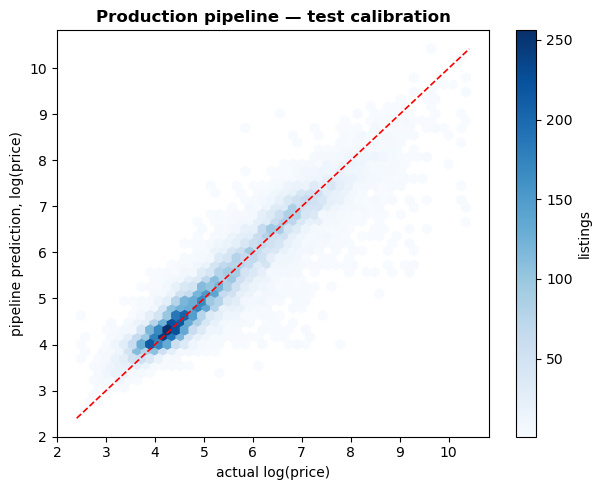

🏃 View run team14_s1402_production_pipeline at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/e2b0bc1b71194c2080500fe3ee7b2724
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Production run logged: e2b0bc1b71194c2080500fe3ee7b2724
  params: hyperparameters + data_version sha256:097b0bbfea3c + lineage to NB02 run
  metrics: 12 values | artifacts: pipeline model, report, manifest, calibration, per-city table


In [15]:
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(test_clean), 15000, replace=False)
sample_rows = test_clean.iloc[idx]
pred_sample = pipe.predict(sample_rows[SERVING_COLUMNS])
y_log_s = np.log1p(apply_price_caps(sample_rows["price"].values, sample_rows["city"], REPORT["price_caps"]))
p_log_s = np.log1p(pred_sample)

with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_production_pipeline") as run:
    mlflow.set_tags({**COMMON_TAGS, "run_kind": "production_training",
                     "model_stage": "candidate", "data_version": DATA_VERSION})
    mlflow.log_params({
        **{f"hp_{k}": v for k, v in CHAMPION_PARAMS.items()},
        "random_state": RANDOM_STATE, "test_size": TEST_SIZE,
        "data_version": DATA_VERSION,
        "raw_uri": RAW_LOCAL if LOCAL_MODE else f"s3://{BUCKET}/{RAW_PREFIX}/Listings.csv",
        "processed_uri": LOCAL_PROCESSED if LOCAL_MODE else f"s3://{BUCKET}/{PROCESSED_PREFIX}",
        "artifacts_uri": LOCAL_ARTIFACTS if LOCAL_MODE else f"s3://{BUCKET}/{ARTIFACTS_PREFIX}",
        "n_train": REPORT["n_train"], "n_test": REPORT["n_test"],
        "pipeline_lib_version": REPORT["pipeline_lib_version"],
        "source_selection_run": BEST["best_run_id"],       # lineage to Notebook 02
        "snapshot_date": "2021-03-01",
    })
    per_city_df = pd.DataFrame(REPORT["per_city"]).set_index("city")
    mlflow.log_metrics({**REPORT["metrics"],
                        "fit_seconds": REPORT["fit_seconds"],
                        "consistency_max_abs_diff": CONSISTENCY_MAX_ABS_DIFF,
                        "test_mape_city_median": float(per_city_df["mape_pct"].median()),
                        "test_r2_log_city_min": float(per_city_df["r2_log"].min())})

    fig, ax = plt.subplots(figsize=(6.2, 5))
    hb = ax.hexbin(y_log_s, p_log_s, gridsize=45, cmap="Blues", mincnt=1)
    lims = [min(y_log_s.min(), p_log_s.min()), max(y_log_s.max(), p_log_s.max())]
    ax.plot(lims, lims, "r--", lw=1.2)
    ax.set_xlabel("actual log(price)"); ax.set_ylabel("pipeline prediction, log(price)")
    ax.set_title("Production pipeline — test calibration", fontweight="bold")
    fig.colorbar(hb, ax=ax, label="listings")
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        fig.savefig(f"{tmp}/production_calibration.png", dpi=110, bbox_inches="tight")
        per_city_df.to_csv(f"{tmp}/per_city_metrics.csv")
        mlflow.log_artifact(f"{tmp}/production_calibration.png", artifact_path="evaluation")
        mlflow.log_artifact(f"{tmp}/per_city_metrics.csv", artifact_path="evaluation")
        mlflow.log_artifact(str(Path(LOCAL_ARTIFACTS, "evaluation_report.json")), artifact_path="evaluation")
        mlflow.log_artifact(str(Path(LOCAL_PROCESSED, "data_manifest.json")), artifact_path="evaluation")
    plt.show(); plt.close()

    # cloudpickle serialization: MLflow's skops default refuses custom transformer
    # classes; cloudpickle + code_paths is the standard route for shipping them.
    mlflow.sklearn.log_model(pipe, name="model",
                             serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
                             code_paths=["src/pipeline_lib.py"],
                             input_example=test_clean[SERVING_COLUMNS].head(2))
    PROD_RUN_ID = run.info.run_id

print(f"Production run logged: {PROD_RUN_ID}")
print(f"  params: hyperparameters + data_version {DATA_VERSION} + lineage to NB02 run")
print(f"  metrics: {len(REPORT['metrics']) + 4} values | artifacts: pipeline model, report, "
      f"manifest, calibration, per-city table")

## 6. Model Registry — Versioning, Lineage, and Approvals

Our target architecture relies on two complementary model registries, both of which are exercised in this notebook:

| Feature | **MLflow Model Registry** *(Executed here)* | **SageMaker Model Registry** *(Step 7, inside the pipeline)* |
| :--- | :--- | :--- |
| **Role** | **Team-facing:** Identifies the champion experiment and tracks full historical lineage. | **Deployment-facing:** Dictates exactly which model package the endpoint infrastructure is allowed to serve. |
| **Versioning** | Sequential versions (`v1, v2, ...`) assigned per registered model name. | Sequential model-package versions within a designated model group. |
| **Lineage Tracker** | Maps: Version → Production Run → Data Hash → Notebook 02 Tuning Run. | Maps: Model Package → Training Job → Pipeline Execution ARN. |
| **Approval Mechanism** | Relies on the `approval_status` tag and the **`@champion` alias** (the deployment pointer). | Relies on state transitions (`PendingManualApproval` → `Approved`) to trigger CI/CD pipelines. |

**The Golden Rule of Deployment:** The architecture dictates that **only explicitly approved models can be deployed.** This governance rule is strictly enforced at two distinct layers:
1.  **Procedurally via AWS:** SageMaker natively refuses to deploy any unapproved model packages. Transitioning a model to `Approved` requires a deliberate, manual action by a human via the AWS Console or API.
2.  **Programmatically in Code:** Our custom deployment helper script actively resolves the `@champion` alias and explicitly blocks deployment if the model's `approval_status` tag is not set to `approved`. 

When a model is first registered, it automatically lands in a `pending_review` state. Promoting it to production is always an intentional, secondary action—exactly mirroring how the process will function in the live production environment.

In [16]:
from mlflow.tracking import MlflowClient
client = MlflowClient()

with contextlib.redirect_stderr(io.StringIO()):        # quiet the registry INFO chatter
    mv = mlflow.register_model(f"runs:/{PROD_RUN_ID}/model", REGISTRY_MODEL_NAME)
client.set_model_version_tag(REGISTRY_MODEL_NAME, mv.version, "approval_status", "pending_review")
for k, v in {"gate_metric": "test_r2_log", "gate_threshold": str(QUALITY_GATE_R2LOG),
             "gate_value": str(REPORT["metrics"]["test_r2_log"]),
             "data_version": DATA_VERSION, "source_selection_run": BEST["best_run_id"],
             "registered_by": f"{TEAM_ID}/{STUDENT_ID}"}.items():
    client.set_model_version_tag(REGISTRY_MODEL_NAME, mv.version, k, v)
client.update_model_version(
    REGISTRY_MODEL_NAME, mv.version,
    description=(f"Airbnb nightly-price regressor (full raw-rows->price pipeline). "
                 f"Trained on {DATA_VERSION}; hyperparameters from NB02 run {BEST['best_run_id'][:8]}; "
                 f"test_r2_log={REPORT['metrics']['test_r2_log']}, "
                 f"test_mape={REPORT['metrics']['test_mape']}%."))

print(f"Registered: {REGISTRY_MODEL_NAME} v{mv.version}  (approval_status = pending_review)")
print("\nLineage chain now auditable end-to-end:")
print(f"  raw data {DATA_VERSION}")
print(f"    -> NB02 selection run {BEST['best_run_id'][:12]}... (hyperparameter provenance)")
print(f"    -> production run {PROD_RUN_ID[:12]}... (this training)")
print(f"    -> {REGISTRY_MODEL_NAME} v{mv.version}")

Registered: iti113-team14-airbnb-price-regressor v5  (approval_status = pending_review)

Lineage chain now auditable end-to-end:
  raw data sha256:097b0bbfea3c
    -> NB02 selection run 3799806706b9... (hyperparameter provenance)
    -> production run e2b0bc1b7119... (this training)
    -> iti113-team14-airbnb-price-regressor v5


In [17]:
# --- Approval: a deliberate, separate act (console button / API call / CI approval job)
client.set_model_version_tag(REGISTRY_MODEL_NAME, mv.version, "approval_status", "approved")
client.set_model_version_tag(REGISTRY_MODEL_NAME, mv.version, "approved_by", f"{TEAM_ID}/{STUDENT_ID}")
client.set_registered_model_alias(REGISTRY_MODEL_NAME, "champion", mv.version)
print(f"APPROVED: {REGISTRY_MODEL_NAME} v{mv.version} -> alias @champion "
      f"(the pointer deployment automation resolves)")

APPROVED: iti113-team14-airbnb-price-regressor v5 -> alias @champion (the pointer deployment automation resolves)


In [18]:
# --- "Only approved versions can be deployed", enforced in code:
def get_deployable_model(name, alias="champion"):
    mv = client.get_model_version_by_alias(name, alias)
    status = mv.tags.get("approval_status")
    if status != "approved":
        raise PermissionError(f"{name} v{mv.version} has approval_status={status!r} — deployment refused.")
    print(f"[OK] {name} v{mv.version} is approved -> loading models:/{name}@{alias}")
    return mlflow.sklearn.load_model(f"models:/{name}@{alias}"), mv

champion, champion_version = get_deployable_model(REGISTRY_MODEL_NAME)

demo = test_clean.groupby("city", group_keys=False).head(1).head(4)
out = pd.DataFrame({"city": demo["city"].values,
                    "currency": demo["city"].map(CURRENCY).values,
                    "advertised": demo["price"].round(0).astype(int).values,
                    "suggested_fair_rate": champion.predict(demo[SERVING_COLUMNS]).round(0).astype(int)})
print("\nChampion (loaded from the registry alias) scoring raw listing rows:")
print(out.to_string(index=False))

[OK] iti113-team14-airbnb-price-regressor v5 is approved -> loading models:/iti113-team14-airbnb-price-regressor@champion



Champion (loaded from the registry alias) scoring raw listing rows:
     city currency  advertised  suggested_fair_rate
    Paris      EUR          60                   71
   Sydney      AUD         144                  167
Hong Kong      HKD         523                  432
 New York      USD        1225                  798


  5%|=                   | 237/5000 [00:11<03:41]       

  5%|=                   | 260/5000 [00:12<03:38]       

  6%|=                   | 282/5000 [00:13<03:37]       

  6%|=                   | 304/5000 [00:14<03:36]       

  7%|=                   | 326/5000 [00:15<03:35]       

...

 99%|===================| 4928/5000 [03:50<00:03]       

 99%|===================| 4950/5000 [03:51<00:02]       

 99%|===================| 4971/5000 [03:52<00:01]       

100%|===================| 4992/5000 [03:53<00:00]       

SHAP computed: (5000, 88) in 233s
Additivity check (log space): max |base + sum(shap) - pred| = 1.37e-07
Base value = 5.3123 log units  ->  202 in the pooled/mixed-currency sense (NOT a real price; see 6B.1)
GLOBAL FEATURE ATTRIBUTION — champion, parent features, log1p(price) space
                              mean_abs_shap_log  mean_shap_log  p95_abs_shap_log  typical_x_factor
lat_coarse                               0.6855        -0.0308            0.9874              1.98
city                                     0.3945         0.0111            1.1406              1.48
lon_coarse                               0.2924        -0.0218            0.5985              1.34
room_type                                0.1568         0.0024            0.2927              1.17
accommodates                             0.1315         0.0118            0.3164              1.14
bedrooms                                 0.1228         0.0110            0.3785              1.13
amenities (30 flags)    

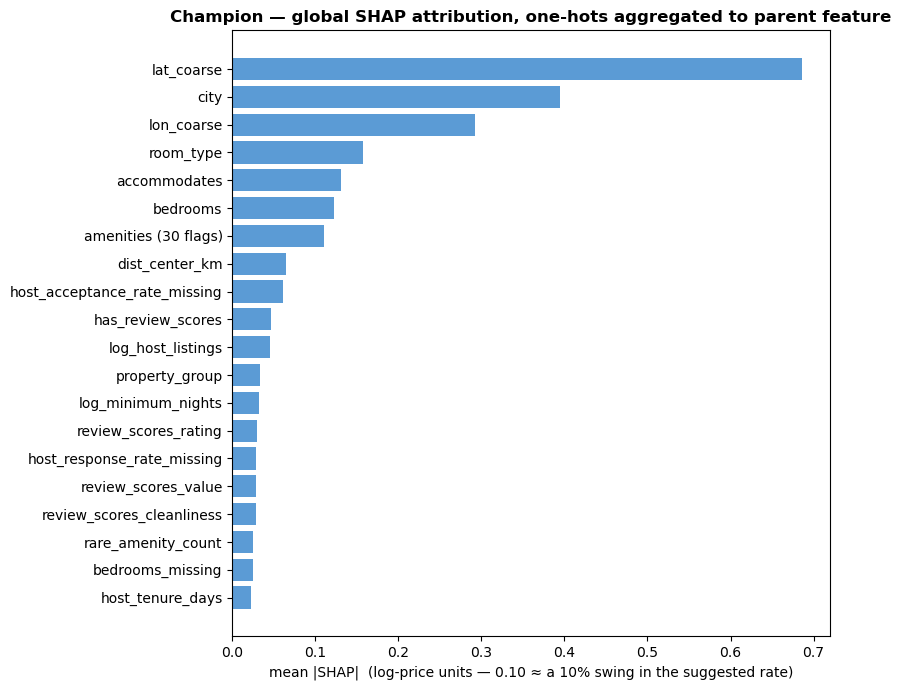

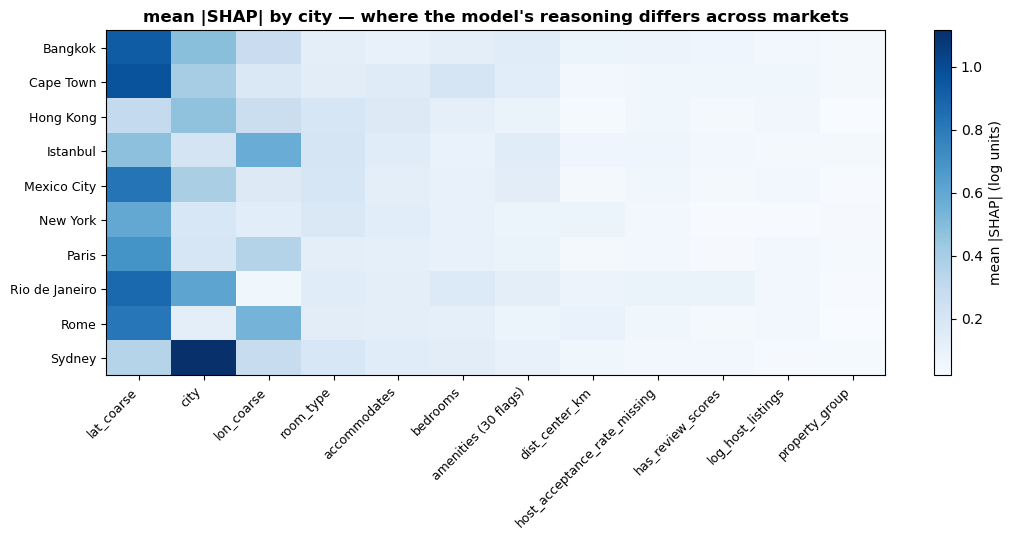

Per-city attribution (mean |SHAP|, log units):
                lat_coarse   city  lon_coarse  room_type  accommodates  bedrooms  amenities (30 flags)  dist_center_km  host_acceptance_rate_missing  has_review_scores  log_host_listings  property_group
Bangkok              0.927  0.485       0.270      0.127         0.104     0.125                 0.147           0.077                         0.082              0.067              0.047           0.042
Cape Town            0.966  0.403       0.182      0.133         0.153     0.203                 0.139           0.052                         0.061              0.059              0.061           0.045
Hong Kong            0.299  0.467       0.262      0.197         0.161     0.120                 0.090           0.037                         0.062              0.045              0.057           0.023
Istanbul             0.475  0.211       0.575      0.206         0.148     0.093                 0.146           0.071                       

Worst 1% cohort: n=50 of 5000  (|residual| >= 1.52 log units, i.e. ratio >= 5x)

Attribution profile — worst 1% vs the rest (mean |SHAP|, log units):
                              worst 1%    rest  ratio
lat_coarse                      0.6560  0.6858   0.96
city                            0.4029  0.3944   1.02
lon_coarse                      0.3186  0.2922   1.09
room_type                       0.2229  0.1561   1.43
accommodates                    0.1550  0.1312   1.18
amenities (30 flags)            0.1537  0.1094   1.40
bedrooms                        0.1159  0.1228   0.94
log_host_listings               0.0863  0.0444   1.94
has_review_scores               0.0770  0.0457   1.68
dist_center_km                  0.0711  0.0643   1.11
host_acceptance_rate_missing    0.0693  0.0612   1.13
log_minimum_nights              0.0539  0.0315   1.71
property_group                  0.0494  0.0331   1.49
host_response_rate_missing      0.0390  0.0289   1.35
rare_amenity_count              0.0298  

🏃 View run team14_s1402_production_pipeline at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/e2b0bc1b71194c2080500fe3ee7b2724
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


Explainability artifacts -> artifacts/explainability
Attached to run e2b0bc1b7119... and tagged on iti113-team14-airbnb-price-regressor v5


In [19]:
# ==========================================================================
# Notebook 03 — Section 6B: Champion Explainability (SHAP)
# --------------------------------------------------------------------------
# Paste these cells into NB03 AFTER cell 30 (`get_deployable_model`) and
# BEFORE cell 52 (the deployment manifest). `# %%` marks a cell boundary.
#
# Explains `champion` — the object resolved from models:/<name>@champion —
# not `pipe`. They are numerically identical here, but the registry object is
# what is actually deployed, and that is what a governance reviewer will ask
# about.
#
# Structural facts this code depends on (verified against src/pipeline_lib.py):
#   champion                          = Pipeline(engineer -> prep -> model)
#   champion.named_steps["model"]     = TransformedTargetRegressor(log1p/expm1)
#   champion.named_steps["model"].regressor_ = the fitted HistGradientBoosting
#   champion[:-1].transform(rows)     = the 88-col float32 DataFrame
#
# shap.TreeExplainer raises InvalidModelError on BOTH the Pipeline and the
# TransformedTargetRegressor. You must reach `.regressor_` yourself.
# Requires shap >= 0.45 for HistGradientBoostingRegressor support.
# ==========================================================================

# %%
# --- 6B.0  Setup: reach the inner regressor, build the design matrix -------
import shap
from pipeline_lib import _slug

SHAP_N_EXPLAIN = 5000     # test rows to attribute (~14 ms/row -> ~70 s)
SHAP_N_BACKGROUND = 200   # interventional reference distribution

hgb_inner = champion.named_steps["model"].regressor_
prep = champion.named_steps["prep"]

rng = np.random.RandomState(RANDOM_STATE)
explain_idx = rng.choice(len(test_clean), SHAP_N_EXPLAIN, replace=False)
explain_rows = test_clean.iloc[explain_idx]
X_explain = champion[:-1].transform(explain_rows[SERVING_COLUMNS])

bg_idx = rng.choice(len(test_clean), SHAP_N_BACKGROUND, replace=False)
X_background = champion[:-1].transform(test_clean.iloc[bg_idx][SERVING_COLUMNS])

# feature_perturbation is a REPORTED CHOICE, not a default to inherit.
# `interventional` breaks the dependence between correlated features by
# integrating over the background; `tree_path_dependent` follows the tree's
# own splits and lets correlated features share credit. This feature set is
# heavily correlated (accommodates / bedrooms / persons_per_bedroom;
# amenity_count / rare_amenity_count / the 30 amenity flags; city one-hots /
# lat_coarse / lon_coarse / neighbourhood_freq), so the two modes give
# materially different attributions. `interventional` is the defensible
# choice for a governance artifact because the reference distribution is
# explicit and auditable. Pass the masker so max_samples is what we claim --
# shap silently subsamples a bare `data=` array to 100 rows.
SHAP_CONFIG = {
    "explainer": "shap.TreeExplainer",
    "shap_version": shap.__version__,
    "feature_perturbation": "interventional",
    "background": f"{SHAP_N_BACKGROUND} test rows, seed {RANDOM_STATE}",
    "n_explained": SHAP_N_EXPLAIN,
    "attribution_space": "log1p(price) — the space the inner regressor learns in",
}

masker = shap.maskers.Independent(X_background, max_samples=SHAP_N_BACKGROUND)
explainer = shap.TreeExplainer(hgb_inner, data=masker,
                               feature_perturbation="interventional")
t0 = time.time()
shap_values = explainer.shap_values(X_explain)
base_value = float(np.ravel(explainer.expected_value)[0])
print(f"SHAP computed: {shap_values.shape} in {time.time()-t0:.0f}s")

# Additivity holds EXACTLY in log space and NOT after expm1. Assert it, so a
# future library change that breaks the guarantee fails loudly here rather
# than producing a quietly wrong chart.
recon = base_value + shap_values.sum(axis=1)
true_log = hgb_inner.predict(X_explain)
max_dev = float(np.abs(recon - true_log).max())
assert max_dev < 1e-5, f"SHAP additivity violated in log space: {max_dev:.2e}"
print(f"Additivity check (log space): max |base + sum(shap) - pred| = {max_dev:.2e}")
print(f"Base value = {base_value:.4f} log units  ->  {np.expm1(base_value):,.0f} "
      f"in the pooled/mixed-currency sense (NOT a real price; see 6B.1)")

# %%
# --- 6B.1  Aggregate one-hots and amenity flags to parent features ---------
# A raw top-20 on this matrix is ~20 dummy columns. Sum within group first:
# SHAP is additive, so the group total is the feature's true contribution.
amenity_cols = {_slug(a) for a in prep.amenity_vocab_}
onehot_prefixes = {f"{k}_": k for k in prep.onehot_levels_}   # city_, room_type_, ...


def parent_feature(col):
    if col in amenity_cols:
        return "amenities (30 flags)"
    for pref, parent in onehot_prefixes.items():
        if col.startswith(pref):
            return parent
    return col


groups = pd.Series([parent_feature(c) for c in X_explain.columns], index=X_explain.columns)
sv_df = pd.DataFrame(shap_values, columns=X_explain.columns, index=explain_rows.index)
sv_grouped = sv_df.T.groupby(groups).sum().T          # (n_explain, n_parent_features)

# Two scales, both correct, for two audiences:
#   log units      -> the model-development / governance reading
#   x-factor       -> the host-facing reading. pred = expm1(base + sum(shap)),
#                     so exp(shap_j) is feature j's multiplicative effect on
#                     (1 + price); for realistic nightly rates that is the
#                     effect on price to well under a percent.
global_imp = (pd.DataFrame({
        "mean_abs_shap_log": sv_grouped.abs().mean(),
        "mean_shap_log": sv_grouped.mean(),
        "p95_abs_shap_log": sv_grouped.abs().quantile(0.95)})
    .sort_values("mean_abs_shap_log", ascending=False))
global_imp["typical_x_factor"] = np.exp(global_imp["mean_abs_shap_log"]).round(2)

print("GLOBAL FEATURE ATTRIBUTION — champion, parent features, log1p(price) space")
print(global_imp.head(20).round(4).to_string())

top20 = global_imp.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.5, 7))
ax.barh(top20.index, top20["mean_abs_shap_log"], color="#5B9BD5")
ax.set_xlabel("mean |SHAP|  (log-price units — 0.10 ≈ a 10% swing in the suggested rate)")
ax.set_title("Champion — global SHAP attribution, one-hots aggregated to parent feature",
             fontweight="bold")
plt.tight_layout(); plt.show()
fig_global = fig

# %%
# --- 6B.2  Per-city attribution — the interaction claim, evidenced ---------
# The stated reason for choosing an ensemble over Ridge was amenity x city x
# property-type interaction. A pooled summary averages exactly that structure
# away. Per-city is what actually supports the claim -- and it feeds the
# per-market limitations section of the model card.
explain_city = explain_rows["city"].values
top_feats = global_imp.head(12).index.tolist()
city_shap = (sv_grouped[top_feats].abs()
             .groupby(explain_city).mean()
             .reindex(sorted(set(explain_city))))

fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(city_shap.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(top_feats)))
ax.set_xticklabels(top_feats, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(city_shap)))
ax.set_yticklabels(city_shap.index, fontsize=9)
ax.set_title("mean |SHAP| by city — where the model's reasoning differs across markets",
             fontweight="bold")
fig.colorbar(im, ax=ax, label="mean |SHAP| (log units)")
plt.tight_layout(); plt.show()
fig_city = fig

print("Per-city attribution (mean |SHAP|, log units):")
print(city_shap.round(3).to_string())
print("\nRead against the per-city MAPE table: a market where attribution mass "
      "sits on different features AND error is high is a market where the model "
      "is extrapolating a pricing logic learned elsewhere.")

# %%
# --- 6B.3  The extreme-mispricing cohort (NB02 §9.6 follow-up) -------------
# NB02 concluded the worst residuals are a LABEL-quality failure, not a model
# failure. That was an inference from the forensic table. SHAP tests it: if
# the model priced the *features* sensibly while the *label* was junk, the
# attribution profile of the worst cohort should look ordinary.
pred_price = champion.predict(explain_rows[SERVING_COLUMNS])
actual_price = explain_rows["price"].values
resid_log = np.log1p(actual_price) - np.log1p(pred_price)

cut = np.quantile(np.abs(resid_log), 0.99)
worst_mask = np.abs(resid_log) >= cut
print(f"Worst 1% cohort: n={worst_mask.sum()} of {len(resid_log)}  "
      f"(|residual| >= {cut:.2f} log units, i.e. ratio >= {np.exp(cut):.0f}x)")

cohort = pd.DataFrame({
    "worst 1%": sv_grouped[worst_mask].abs().mean(),
    "rest": sv_grouped[~worst_mask].abs().mean()})
cohort["ratio"] = (cohort["worst 1%"] / cohort["rest"]).round(2)
cohort = cohort.sort_values("worst 1%", ascending=False).head(15)
print("\nAttribution profile — worst 1% vs the rest (mean |SHAP|, log units):")
print(cohort.round(4).to_string())
print("\nInterpretation: ratios near 1.0 mean the model reasoned about these "
      "listings the same way it reasons about everything else -- the features "
      "were priced normally and the advertised label is the outlier. That is "
      "the NB02 label-quality diagnosis, now evidenced rather than asserted, "
      "and it is the justification for the model card's 'flag, do not match' "
      "rule on extreme advertised rates. Ratios far from 1.0 would instead "
      "point at a feature the model mishandles in the tail -- a model defect.")

# One worked local explanation. Governance frameworks generally want to see
# that an individual suggestion can be explained to the host it affects.
w = np.where(worst_mask)[0][0]
row_sv = sv_grouped.iloc[w].sort_values(key=np.abs, ascending=False).head(8)
ccy = CURRENCY[explain_rows.iloc[w]["city"]]
print(f"\nWORKED LOCAL EXPLANATION — {explain_rows.iloc[w]['city']} "
      f"{explain_rows.iloc[w]['room_type']}")
print(f"  advertised {ccy} {actual_price[w]:,.0f}  |  suggested {ccy} {pred_price[w]:,.0f}")
for f, v in row_sv.items():
    print(f"    {f:<28s} {v:+.3f} log  ->  x{np.exp(v):.2f} on the suggested rate")

# %%
# --- 6B.4  Persist: artifacts, MLflow run, registry tags, manifest --------
shap_artifacts = Path(LOCAL_ARTIFACTS, "explainability"); shap_artifacts.mkdir(exist_ok=True)
global_imp.to_csv(shap_artifacts / "shap_global_importance.csv")
city_shap.to_csv(shap_artifacts / "shap_by_city.csv")
cohort.to_csv(shap_artifacts / "shap_worst_cohort.csv")
(shap_artifacts / "shap_config.json").write_text(json.dumps(
    {**SHAP_CONFIG, "base_value_log": base_value,
     "additivity_max_dev": max_dev,
     "champion_version": int(champion_version.version),
     "data_version": DATA_VERSION}, indent=2))
fig_global.savefig(shap_artifacts / "shap_global.png", dpi=110, bbox_inches="tight")
fig_city.savefig(shap_artifacts / "shap_by_city.png", dpi=110, bbox_inches="tight")

# Attach to the SAME production run the champion was registered from, so the
# explanation travels with the model version rather than living in a notebook.
with mlflow.start_run(run_id=PROD_RUN_ID):
    mlflow.log_artifacts(str(shap_artifacts), artifact_path="explainability")
    mlflow.log_params({f"shap_{k}": v for k, v in SHAP_CONFIG.items()})
    mlflow.log_metrics({
        "shap_additivity_max_dev": max_dev,
        "shap_top1_mean_abs": float(global_imp["mean_abs_shap_log"].iloc[0]),
        "shap_concentration_top5": float(
            global_imp["mean_abs_shap_log"].head(5).sum()
            / global_imp["mean_abs_shap_log"].sum()),
    })

client.set_model_version_tag(REGISTRY_MODEL_NAME, champion_version.version,
                             "explainability", "shap_interventional")
client.set_model_version_tag(REGISTRY_MODEL_NAME, champion_version.version,
                             "explainability_run", PROD_RUN_ID)

# Baseline for the attribution-drift monitor in §10.2: if the live feature mix
# shifts, mean|SHAP| per feature moves before accuracy visibly degrades.
(shap_artifacts / "attribution_baseline.json").write_text(json.dumps({
    "data_version": DATA_VERSION,
    "champion_version": int(champion_version.version),
    "mean_abs_shap": global_imp["mean_abs_shap_log"].round(5).to_dict(),
    "alert_rule": "flag any parent feature whose weekly mean|SHAP| moves >30% "
                  "from this baseline, or any change in the top-5 ranking",
}, indent=2))

print(f"Explainability artifacts -> {shap_artifacts}")
print(f"Attached to run {PROD_RUN_ID[:12]}... and tagged on "
      f"{REGISTRY_MODEL_NAME} v{champion_version.version}")

# --------------------------------------------------------------------------
# Then add to `deployment_manifest` in cell 52:
#
#     "explainability": {
#         "method": "TreeSHAP (interventional)",
#         "shap_version": shap.__version__,
#         "background": SHAP_CONFIG["background"],
#         "n_explained": SHAP_N_EXPLAIN,
#         "attribution_space": "log1p(price)",
#         "artifacts": "artifacts/explainability/",
#         "attribution_baseline": "artifacts/explainability/attribution_baseline.json",
#     },
# --------------------------------------------------------------------------

## 7. The SageMaker Pipeline — Parameterized, Gated, Registering

When transitioning to AWS, the exact scripts executed in Step 3 are orchestrated into a fully managed, **parameterized SageMaker Pipeline**:

| Step | Action | I/O Flow |
| :--- | :--- | :--- |
| **1 `PreprocessData`** *(ProcessingStep)* | Executes `preprocess.py` on an `ml.m5.large` instance. | Reads `/raw/Listings.csv` → Writes to `/processed/` (cleaned data splits and manifest). |
| **2 `TrainModel`** *(TrainingStep)* | Runs `train.py`, injecting the hyperparameters dynamically as **pipeline parameters**. | Reads from `/processed/` → Writes to the model channel (outputs `model_pipeline.joblib` and a metrics report → bundled as an S3 `model.tar.gz`). |
| **3 `R2LogQualityGate`** *(ConditionStep)* | Evaluates performance by comparing the regex-extracted `test_r2_log` metric against our predefined minimum gate threshold. | — |
| **4 `RegisterModel`** *(ModelStep, Gated)* | If the quality condition passes, it registers the model artifact into the SageMaker Model Registry with a status of **`PendingManualApproval`**. | Reads model artifact → Writes to Model Registry. |

Because both the champion hyperparameters and the quality gate threshold are defined as `Parameter` objects, tweaking these values for a new training run is simply an *execution argument*—requiring zero code changes. This literally fulfills the architectural requirement for "parameterized training jobs." 

To guarantee strict provenance, all scripts (including `pipeline_lib.py`) are pre-staged in S3 and dynamically pulled down into `pipeline_src/`, ensuring the pipeline executes the exact, reviewed code versions. Additionally, the `ProcessingStep` explicitly mounts this script directory to `/opt/ml/processing/input/code` so that `preprocess.py` can seamlessly import the shared pipeline module. 

*Note:* When running in `LOCAL_MODE`, these cells will safely bypass execution and print a `[SKIP]` notification. They are designed to execute verbatim on SageMaker Studio.

In [20]:
if LOCAL_MODE:
    print("[SKIP] LOCAL_MODE — S3 script placement runs on SageMaker Studio.")
else:
    s3 = boto3.client("s3")
    SCRIPTS_S3_PREFIX = f"{PREFIX}/pipeline_src"
    SCRIPTS_S3_URI = f"s3://{BUCKET}/{SCRIPTS_S3_PREFIX}"
    FILES = ["pipeline_lib.py", "preprocess.py", "train.py", "inference.py"]
    for fn in FILES:
        s3.upload_file(f"src/{fn}", BUCKET, f"{SCRIPTS_S3_PREFIX}/{fn}")
        print(f"uploaded src/{fn} -> {SCRIPTS_S3_URI}/{fn}")

    # Immutable raw extract in /raw (upload once; never overwritten by the pipeline)
    RAW_DATA_URI = f"s3://{BUCKET}/{RAW_PREFIX}/Listings.csv"
    try:
        s3.head_object(Bucket=BUCKET, Key=f"{RAW_PREFIX}/Listings.csv")
        print(f"raw extract already in place: {RAW_DATA_URI}")
    except Exception:
        s3.upload_file(RAW_LOCAL, BUCKET, f"{RAW_PREFIX}/Listings.csv")
        print(f"uploaded raw extract -> {RAW_DATA_URI}")

uploaded src/pipeline_lib.py -> s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/pipeline_src/pipeline_lib.py
uploaded src/preprocess.py -> s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/pipeline_src/preprocess.py
uploaded src/train.py -> s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/pipeline_src/train.py
uploaded src/inference.py -> s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/pipeline_src/inference.py
raw extract already in place: s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/raw/Listings.csv


In [21]:
if LOCAL_MODE:
    print("[SKIP] LOCAL_MODE — pipeline_src/ verification happens on Studio.")
else:
    import shutil
    LOCAL_PIPELINE_SRC = "pipeline_src"
    if Path(LOCAL_PIPELINE_SRC).exists():
        shutil.rmtree(LOCAL_PIPELINE_SRC)
    Path(LOCAL_PIPELINE_SRC).mkdir(parents=True)
    for fn in FILES:
        s3.download_file(BUCKET, f"{SCRIPTS_S3_PREFIX}/{fn}", f"{LOCAL_PIPELINE_SRC}/{fn}")
        print(f"downloaded {SCRIPTS_S3_URI}/{fn} -> {LOCAL_PIPELINE_SRC}/{fn}")
    print("Pipeline will use the S3-preplaced copies in pipeline_src/, not the notebook's src/.")

downloaded s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/pipeline_src/pipeline_lib.py -> pipeline_src/pipeline_lib.py
downloaded s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/pipeline_src/preprocess.py -> pipeline_src/preprocess.py


downloaded s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/pipeline_src/train.py -> pipeline_src/train.py
downloaded s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/pipeline_src/inference.py -> pipeline_src/inference.py
Pipeline will use the S3-preplaced copies in pipeline_src/, not the notebook's src/.


In [22]:
if LOCAL_MODE:
    print("[SKIP] LOCAL_MODE — pipeline definition executes on Studio (shown in full).")
else:
    from sagemaker.workflow.pipeline import Pipeline
    from sagemaker.workflow.steps import ProcessingStep, TrainingStep
    from sagemaker.workflow.conditions import ConditionGreaterThanOrEqualTo
    from sagemaker.workflow.condition_step import ConditionStep
    from sagemaker.workflow.parameters import ParameterFloat, ParameterInteger
    from sagemaker.workflow.model_step import ModelStep
    from sagemaker.workflow.pipeline_context import PipelineSession
    from sagemaker.processing import FrameworkProcessor, ProcessingInput, ProcessingOutput
    from sagemaker.sklearn.estimator import SKLearn
    from sagemaker.model import Model

    pipeline_session = PipelineSession()
    PIPELINE_ROOT = f"s3://{BUCKET}/{PROCESSED_PREFIX}/pipeline"

    # ============================================================
    # Why FrameworkProcessor and not SKLearnProcessor here
    # ------------------------------------------------------------
    # The reference notebook uses SKLearnProcessor with code=<one file>,
    # which is correct there because its preprocess.py is self-contained.
    # Ours imports pipeline_lib -- the single source of truth shared by
    # preprocess/train/inference -- so a ScriptProcessor would need a second
    # input channel to carry it, and that channel collides with the SDK's
    # own "code" channel on /opt/ml/processing/input/code.
    #
    # FrameworkProcessor takes source_dir=, tars the whole directory, and
    # extracts it into the ONE code channel. pipeline_lib.py therefore lands
    # beside preprocess.py, which the script's existing
    #     HERE = os.path.dirname(os.path.abspath(__file__)); sys.path.append(HERE)
    # already resolves. No second input, no collision, no script edit.
    #
    # code_location keeps the packaged source in the project bucket rather
    # than the SDK default bucket (SKLearnProcessor has no such parameter --
    # a second reason the ScriptProcessor route was awkward here).
    # ============================================================

    # --- Parameters: champion defaults from Step 0A, every one overridable per execution
    p_lr      = ParameterFloat(name="LearningRate",     default_value=CHAMPION_PARAMS["learning_rate"])
    p_leaves  = ParameterInteger(name="MaxLeafNodes",   default_value=CHAMPION_PARAMS["max_leaf_nodes"])
    p_iter    = ParameterInteger(name="MaxIter",        default_value=CHAMPION_PARAMS["max_iter"])
    p_minleaf = ParameterInteger(name="MinSamplesLeaf", default_value=CHAMPION_PARAMS["min_samples_leaf"])
    p_l2      = ParameterFloat(name="L2Regularization", default_value=CHAMPION_PARAMS["l2_regularization"])
    p_gate    = ParameterFloat(name="QualityGateR2Log", default_value=QUALITY_GATE_R2LOG)

    # --- Sanity: the packaged directory must actually contain the library
    for _need in ("preprocess.py", "pipeline_lib.py"):
        assert Path(LOCAL_PIPELINE_SRC, _need).exists(), \
            f"{_need} missing from {LOCAL_PIPELINE_SRC}/ — re-run the upload/download cells"
    print(f"source_dir {LOCAL_PIPELINE_SRC}/ contains: "
          f"{sorted(p.name for p in Path(LOCAL_PIPELINE_SRC).iterdir())}")

    # --- Step 1: ProcessingStep (raw -> versioned cleaned splits)
    processor = FrameworkProcessor(
        estimator_cls=SKLearn, framework_version="1.2-1",
        instance_type=PROCESSING_INSTANCE_TYPE, instance_count=1,
        role=role, sagemaker_session=pipeline_session,
        code_location=f"s3://{BUCKET}/{PREFIX}/pipeline_code",
        base_job_name=f"iti113-{TEAM_ID}-{STUDENT_ID}-process")

    proc_args = processor.run(
        code="preprocess.py",              # relative to source_dir
        source_dir=LOCAL_PIPELINE_SRC,     # ships pipeline_lib.py alongside it
        inputs=[ProcessingInput(input_name="raw", source=RAW_DATA_URI,
                                destination="/opt/ml/processing/input")],
        outputs=[ProcessingOutput(output_name="processed", source="/opt/ml/processing/output",
                                  destination=f"{PIPELINE_ROOT}/processed")],
        arguments=["--input", "/opt/ml/processing/input/Listings.csv",
                   "--output-dir", "/opt/ml/processing/output",
                   "--test-size", str(TEST_SIZE), "--random-state", str(RANDOM_STATE)])
    step_process = ProcessingStep(name="PreprocessData", step_args=proc_args)

    # --- Step 2: TrainingStep (parameterized; regex metric capture feeds the gate)
    # framework_version pins the container's sklearn line; the pipeline artifact is
    # SERIALIZED BY THIS CONTAINER, so endpoint/container versions stay matched.
    estimator = SKLearn(
        entry_point="train.py", source_dir=LOCAL_PIPELINE_SRC, framework_version="1.2-1",
        instance_type=TRAINING_INSTANCE_TYPE, instance_count=1, role=role,
        base_job_name=f"iti113-{TEAM_ID}-{STUDENT_ID}-train", sagemaker_session=pipeline_session,
        code_location=f"s3://{BUCKET}/{PREFIX}/pipeline_code",
        hyperparameters={"learning-rate": p_lr, "max-leaf-nodes": p_leaves, "max-iter": p_iter,
                         "min-samples-leaf": p_minleaf, "l2-regularization": p_l2,
                         "gate-r2": p_gate, "random-state": RANDOM_STATE,
                         "team-id": TEAM_ID, "student-id": STUDENT_ID},
        environment={"TEAM_ID": TEAM_ID, "STUDENT_ID": STUDENT_ID, "SEMESTER": SEMESTER},
        metric_definitions=[
            {"Name": "test_mae_log",  "Regex": "test_mae_log: ([0-9\\.]+)"},
            {"Name": "test_rmse_log", "Regex": "test_rmse_log: ([0-9\\.]+)"},
            {"Name": "test_r2_log",   "Regex": "test_r2_log: ([0-9\\.]+)"},
            {"Name": "test_mape",     "Regex": "test_mape: ([0-9\\.]+)"},
        ],
        tags=[{"Key": "Course", "Value": COURSE}, {"Key": "Semester", "Value": SEMESTER},
              {"Key": "Team", "Value": TEAM_ID}, {"Key": "Student", "Value": STUDENT_ID}])
    processed_uri = step_process.properties.ProcessingOutputConfig.Outputs["processed"].S3Output.S3Uri
    step_train = TrainingStep(
        name="TrainModel", estimator=estimator,
        inputs={"train": sagemaker.inputs.TrainingInput(s3_data=processed_uri, content_type="text/csv"),
                "test":  sagemaker.inputs.TrainingInput(s3_data=processed_uri, content_type="text/csv")})
    print("Steps 1-2 defined (FrameworkProcessor ProcessingStep, parameterized TrainingStep).")


See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


source_dir pipeline_src/ contains: ['inference.py', 'pipeline_lib.py', 'preprocess.py', 'train.py']


Steps 1-2 defined (FrameworkProcessor ProcessingStep, parameterized TrainingStep).


In [23]:
if LOCAL_MODE:
    print("[SKIP] LOCAL_MODE — gate + registration + upsert execute on Studio (shown in full).")
else:
    # --- Step 3: ModelStep — register into SageMaker Model Registry (deployment-facing)
    model = Model(image_uri=estimator.training_image_uri(REGION),
                  model_data=step_train.properties.ModelArtifacts.S3ModelArtifacts,
                  sagemaker_session=pipeline_session, role=role,
                  entry_point="inference.py", source_dir=LOCAL_PIPELINE_SRC)
    step_register = ModelStep(
        name="RegisterModel",
        step_args=model.register(
            content_types=["application/json"], response_types=["application/json"],
            inference_instances=["ml.m5.large"], transform_instances=["ml.m5.large"],
            model_package_group_name=MODEL_PACKAGE_GROUP,
            approval_status="PendingManualApproval"))

    # --- Step 4: ConditionStep — the same 0.65 R2_log gate as Notebook 02
    condition = ConditionGreaterThanOrEqualTo(
        left=step_train.properties.FinalMetricDataList["test_r2_log"].Value, right=p_gate)
    step_condition = ConditionStep(name="R2LogQualityGate", conditions=[condition],
                                   if_steps=[step_register], else_steps=[])

    pipeline = Pipeline(name=PIPELINE_NAME,
                        parameters=[p_lr, p_leaves, p_iter, p_minleaf, p_l2, p_gate],
                        steps=[step_process, step_train, step_condition],
                        sagemaker_session=pipeline_session)
    pipeline.upsert(role_arn=role)
    print(f'Pipeline "{PIPELINE_NAME}" upserted — visible in Studio under Pipelines.')

See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.


INFO:sagemaker.processing:Uploaded pipeline_src to s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/pipeline_code/iti113-team14-airbnb-price/code/5693c196f8988f9858bab156272b852e66065e77bf61dfb90974e9b334287b88/sourcedir.tar.gz


INFO:sagemaker.processing:runproc.sh uploaded to s3://sagemaker-ap-southeast-1-044528205969/iti113-team14-airbnb-price/code/0d453f34961f367d397854869f8b2673fec384779e12ff533eda22686866dfa6/runproc.sh


INFO:sagemaker.processing:Uploaded pipeline_src to s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/pipeline_code/iti113-team14-airbnb-price/code/289c1b3a653f30bf9a739392bdc4671559435790d33ba385e49ee06a2d820299/sourcedir.tar.gz


INFO:sagemaker.processing:runproc.sh uploaded to s3://sagemaker-ap-southeast-1-044528205969/iti113-team14-airbnb-price/code/0d453f34961f367d397854869f8b2673fec384779e12ff533eda22686866dfa6/runproc.sh


Pipeline "iti113-team14-airbnb-price" upserted — visible in Studio under Pipelines.


### 7.2 Execute and monitor

`pipeline.start()` accepts any parameter overrides — a hyperparameter sweep or a stricter gate is one call, zero code changes. The monitor loop polls step status every 30 s (expect ~15–25 minutes end-to-end on `ml.m5.large`).

In [24]:
if LOCAL_MODE:
    print("[SKIP] LOCAL_MODE — Step 3 already executed these exact scripts locally; the managed run happens on Studio.")
else:
    execution = pipeline.start(parameters={
        "LearningRate": CHAMPION_PARAMS["learning_rate"],
        "MaxLeafNodes": CHAMPION_PARAMS["max_leaf_nodes"],
        "MaxIter": CHAMPION_PARAMS["max_iter"],
        "MinSamplesLeaf": CHAMPION_PARAMS["min_samples_leaf"],
        "L2Regularization": CHAMPION_PARAMS["l2_regularization"],
        "QualityGateR2Log": QUALITY_GATE_R2LOG})
    print(f"Execution ARN: {execution.arn}")
    prev = {}
    while True:
        status = execution.describe()["PipelineExecutionStatus"]
        steps = execution.list_steps()
        if isinstance(steps, dict):
            steps = steps.get("PipelineExecutionSteps", [])
        for step in steps:
            n, s = step["StepName"], step["StepStatus"]
            if prev.get(n) != s:
                print(f"{n:<22} {s}"); prev[n] = s
        if status in ("Succeeded", "Failed", "Stopped"):
            print(f"\nPipeline Status: {status}"); break
        time.sleep(30)

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.


Execution ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:pipeline/iti113-team14-airbnb-price/execution/jj4npt6fhkga


PreprocessData         Executing


TrainModel             Executing
PreprocessData         Succeeded


RegisterModel-RepackModel-0 Executing
R2LogQualityGate       Succeeded
TrainModel             Succeeded


RegisterModel-RegisterModel Succeeded
RegisterModel-RepackModel-0 Succeeded

Pipeline Status: Succeeded


In [25]:
# ================================================================
# PreprocessData reached "Executing" this time, so a ProcessingJob EXISTS
# and the container produced logs. This pulls them.
# Auto-targets the most recent execution — no ARN to paste.
# ================================================================
sm = boto3.client("sagemaker", region_name=REGION)
logs = boto3.client("logs", region_name=REGION)

ex = sm.list_pipeline_executions(PipelineName=PIPELINE_NAME, SortBy="CreationTime",
                                 SortOrder="Descending", MaxResults=1)["PipelineExecutionSummaries"][0]
print(f"execution: {ex['PipelineExecutionArn'].rsplit('/', 1)[-1]}  ({ex['PipelineExecutionStatus']})\n")

steps = sm.list_pipeline_execution_steps(
    PipelineExecutionArn=ex["PipelineExecutionArn"])["PipelineExecutionSteps"]
job_name = None
for s in steps:
    print(f"{s['StepName']:20s} {s['StepStatus']}")
    if s.get("FailureReason"):
        print(f"  reason: {s['FailureReason']}")
    if s["StepName"] == "PreprocessData":
        arn = s.get("Metadata", {}).get("ProcessingJob", {}).get("Arn", "")
        job_name = arn.rsplit("/", 1)[-1] if arn else None

if not job_name:
    raise SystemExit("Still no ProcessingJob ARN — the step died before job creation again.")

job = sm.describe_processing_job(ProcessingJobName=job_name)
print(f"\njob           : {job_name}")
print(f"status        : {job['ProcessingJobStatus']}")
print(f"FailureReason : {job.get('FailureReason', '(none)')}")
print(f"ExitMessage   : {job.get('ExitMessage', '(none)')}")
res = job["ProcessingResources"]["ClusterConfig"]
print(f"resources     : {res['InstanceType']} x{res['InstanceCount']}, {res['VolumeSizeInGB']} GB EBS")
print(f"entrypoint    : {job['AppSpecification'].get('ContainerEntrypoint')}")
print(f"container args: {job['AppSpecification'].get('ContainerArguments')}")
print("\ninputs as the container received them:")
for i in job.get("ProcessingInputs", []):
    si = i.get("S3Input", {})
    print(f"  {i['InputName']:12s} {si.get('S3Uri','')}\n  {'':12s} -> {si.get('LocalPath','')}")

# --- Container stdout/stderr: the Python traceback lives here
print("\n" + "=" * 70 + "\nCONTAINER LOGS\n" + "=" * 70)
group = "/aws/sagemaker/ProcessingJobs"
try:
    streams = logs.describe_log_streams(logGroupName=group, logStreamNamePrefix=job_name,
                                        orderBy="LogStreamName")["logStreams"]
    if not streams:
        print("No log streams — container never started (image pull / IAM / resource error).")
    for st in streams:
        print(f"--- {st['logStreamName']} ---")
        tok, n = None, 0
        while n < 600:
            kw = dict(logGroupName=group, logStreamName=st["logStreamName"],
                      startFromHead=True, limit=200)
            if tok:
                kw["nextToken"] = tok
            r = logs.get_log_events(**kw)
            if not r["events"]:
                break
            for e in r["events"]:
                print("   ", e["message"].rstrip())
            n += len(r["events"])
            if r["nextForwardToken"] == tok:
                break
            tok = r["nextForwardToken"]
except logs.exceptions.ResourceNotFoundException:
    print(f"Log group {group} not found — container never started.")

execution: jj4npt6fhkga  (Succeeded)

RegisterModel-RegisterModel Succeeded
RegisterModel-RepackModel-0 Succeeded
R2LogQualityGate     Succeeded
TrainModel           Succeeded
PreprocessData       Succeeded

job           : pipelines-jj4npt6fhkga-PreprocessData-jm98TYYxvO
status        : Completed
FailureReason : (none)
ExitMessage   : (none)
resources     : ml.m5.large x1, 30 GB EBS
entrypoint    : ['/bin/bash', '/opt/ml/processing/input/entrypoint/runproc.sh']
container args: ['--input', '/opt/ml/processing/input/Listings.csv', '--output-dir', '/opt/ml/processing/output', '--test-size', '0.2', '--random-state', '42']

inputs as the container received them:
  raw          s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/raw/Listings.csv
               -> /opt/ml/processing/input
  code         s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/pipeline_code/iti113-team14-airbnb-price/code/289c1b3a653f30bf9a739392bdc4671559435790d33ba385e49ee06a2d820299/sourcedir.tar.gz
   

--- pipelines-jj4npt6fhkga-PreprocessData-jm98TYYxvO/algo-1-1787674365 ---
    pipeline_lib v1.0.0 | reading /opt/ml/processing/input/Listings.csv
    raw rows: 279,712 | data_version: sha256:097b0bbfea3c
      clean: near-duplicate removal       - 356 rows  (same host_id + exact coords + identical name -> kept first)
  clean: PII drop                     -   0 rows  (dropped ['name', 'host_location', 'host_id'])
  clean: Tier-1 price validity        - 113 rows  (price <= 0 is not an advertised rate)
  clean: Tier-1 capacity validity     -   0 rows  (accommodates <= 0 is not rentable)
  clean: sparsity drop                -   0 rows  (columns > 80% missing dropped: ['district'])
    clean rows: 279,243 (469 removed)
    train: 223,394 rows | test: 55,849 rows
    wrote train.csv, test.csv, data_manifest.json


### 7.3 Post-pipeline MLflow logging

The managed run kept MLflow out of its containers, so the notebook now closes the tracking loop: it reads the completed **training job** (captured metrics, hyperparameters actually used, the `model.tar.gz` S3 URI, execution ARN) and logs them as an MLflow run in the same team experiment — tagged `run_type=sagemaker_pipeline_run` so managed and local runs sit side-by-side in the comparison table with full data-version lineage.

In [26]:
if LOCAL_MODE:
    print("[SKIP] LOCAL_MODE — the Step 5 production run already logged this training; job-metadata logging happens on Studio.")
else:
    steps = execution.list_steps()
    if isinstance(steps, dict):
        steps = steps.get("PipelineExecutionSteps", [])
    train_step = next(s for s in steps if s["StepName"] == "TrainModel" and s["StepStatus"] == "Succeeded")
    job_name = train_step["Metadata"]["TrainingJob"]["Arn"].rsplit("/", 1)[-1]
    job = sm_client.describe_training_job(TrainingJobName=job_name)
    captured = {m["MetricName"]: float(m["Value"]) for m in job.get("FinalMetricDataList", [])}
    model_s3 = job["ModelArtifacts"]["S3ModelArtifacts"]
    print(f"Training job {job_name}\n  captured: {captured}\n  artifact: {model_s3}")

    with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_sagemaker_pipeline_run") as run:
        mlflow.set_tags({**COMMON_TAGS, "run_type": "sagemaker_pipeline_run",
                         "pipeline_execution_arn": execution.arn, "training_job": job_name})
        mlflow.log_params({k: v for k, v in job["HyperParameters"].items()})
        mlflow.log_params({"model_artifact_s3": model_s3,
                           "raw_uri": RAW_DATA_URI, "processed_uri": f"{PIPELINE_ROOT}/processed"})
        mlflow.log_metrics(captured)
    print(f"Logged managed run to MLflow: {run.info.run_id}")

Training job pipelines-jj4npt6fhkga-TrainModel-HuMKdZYNou
  captured: {'test_mape': 33.40999984741211, 'test_r2_log': 0.8708000183105469, 'test_mae_log': 0.3206999897956848, 'test_rmse_log': 0.45100000500679016}
  artifact: s3://sagemaker-ap-southeast-1-044528205969/pipelines-jj4npt6fhkga-TrainModel-HuMKdZYNou/output/model.tar.gz


🏃 View run team14_s1402_sagemaker_pipeline_run at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/f58372db6a984979a9219db082817fd9
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Logged managed run to MLflow: f58372db6a984979a9219db082817fd9


## 8. Serving — from the Registry to a Serverless Endpoint

**The Transition, Step by Step.** A model version isn't simply "deployed" It is *promoted*, with the endpoint strictly following the state of the registry:

1.  The gated pipeline lands a new package into the SageMaker Model Registry with the status **`PendingManualApproval`**, rendering it intentionally inert. This package bundles both the model artifact (`model.tar.gz`, containing `model_pipeline.joblib`) *and* the required inference code (`inference.py` + `pipeline_lib.py`). As a result, the serving container deserializes the exact same pipeline object that was proven faithful in Step 4.
2.  Next, a **human approves** the model (either via the Studio console or through the `update_model_package` API call below). This decision is based on reviewing the MLflow run: comparing metrics against the gate, examining the per-city breakdown, checking the data version, and verifying the lineage. This approval is the *only* manual action required in the entire system—everything before and after is fully automated.
3.  Approval flips the status to `ModelApprovalStatus=Approved`, which acts as the trigger for deployment automation (covered in Step 10). Here, we execute the deployment explicitly: calling `ModelPackage.deploy(...)` creates both the endpoint configuration and the endpoint itself using the **approved package ARN**. If you attempt to deploy an unapproved package, the platform rejects the call. This mirrors the code-level gate from Step 6, enforcing the strict rule that *only approved versions can be deployed*.

**Why Serverless Inference? A Deliberate Choice Over Provisioned Real-Time.** 
Our traffic profile is typical for demos or coursework: short bursts of activity separated by hours or even days of absolute silence. A provisioned real-time instance (like an `ml.m5.large`) bills 24/7 regardless of traffic. In contrast, a serverless endpoint **scales to zero** and bills strictly per-invocation-millisecond. This means idle time costs ~$0, while the system can still automatically scale up to handle burst concurrency. 

The trade-off we accept here is the **cold start**—the time required to pull the container and deserialize the pipeline in the `model_fn` (which typically takes a few seconds to roughly a minute on the first invocation and is tracked via the `ModelSetupTime` metric). For our use case, this latency is perfectly acceptable (and if this were to become a high-traffic production product, we could easily mitigate it using provisioned concurrency). 

**Sizing the Endpoint:** 
*   `memory_size_in_mb=3072` comfortably accommodates our ~15 MB pipeline alongside the working memory footprint required by pandas and scikit-learn. 
*   `max_concurrency=5` provides a hard cap to prevent runaway costs while easily exceeding any plausible load generated by a demo.

In [27]:
if LOCAL_MODE:
    print("[SKIP] LOCAL_MODE — Model Registry approval happens on Studio; the Step 6 MLflow approval flow is the local equivalent.")
else:
    pkgs = sm_client.list_model_packages(ModelPackageGroupName=MODEL_PACKAGE_GROUP,
                                         SortBy="CreationTime", SortOrder="Descending",
                                         MaxResults=1)["ModelPackageSummaryList"]
    if not pkgs:
        raise RuntimeError("No model packages found — did the pipeline pass the quality gate?")
    pkg_arn = pkgs[0]["ModelPackageArn"]
    print(f"Latest package: {pkg_arn}\nStatus: {pkgs[0]['ModelApprovalStatus']}")
    sm_client.update_model_package(ModelPackageArn=pkg_arn, ModelApprovalStatus="Approved")
    print("Approved — deployment automation may now act on this version (and only this version).")

Latest package: arn:aws:sagemaker:ap-southeast-1:044528205969:model-package/iti113-team14-airbnb-price-models/21
Status: PendingManualApproval


Approved — deployment automation may now act on this version (and only this version).


In [28]:

try:
    sm_client.delete_endpoint_config(
        EndpointConfigName=ENDPOINT_NAME
    )

    print(
        f"Deleted endpoint config: {ENDPOINT_NAME}"
    )

except botocore.exceptions.ClientError as e:

    if "Could not find" in str(e):
        print("Endpoint config does not exist.")

    else:
        raise

Deleted endpoint config: iti113-team14-airbnb-price-sls


In [29]:
if LOCAL_MODE:
    print("[SKIP] LOCAL_MODE — endpoint creation happens on Studio; Step 8.2 smoke-tests the identical serving code locally.")
else:
    from sagemaker import ModelPackage
    from sagemaker.serverless import ServerlessInferenceConfig

    deployable = ModelPackage(role=role, model_package_arn=pkg_arn,
                              sagemaker_session=sagemaker.Session())
    serverless_cfg = ServerlessInferenceConfig(memory_size_in_mb=3072, max_concurrency=5)
    print(f"Deploying serverless endpoint {ENDPOINT_NAME} (3-5 minutes)...")
    predictor = deployable.deploy(serverless_inference_config=serverless_cfg,
                                  endpoint_name=ENDPOINT_NAME)
    print(f"Endpoint ready: {ENDPOINT_NAME} — ~$0 when idle, billed per invocation.")

See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


INFO:sagemaker:Creating model with name: iti113-team14-airbnb-price-models-2026-08-25-16-24-15-889


Deploying serverless endpoint iti113-team14-airbnb-price-sls (3-5 minutes)...


INFO:sagemaker:Creating endpoint-config with name iti113-team14-airbnb-price-sls


INFO:sagemaker:Creating endpoint with name iti113-team14-airbnb-price-sls


...

-

-

-

!

Endpoint ready: iti113-team14-airbnb-price-sls — ~$0 when idle, billed per invocation.


In [30]:
# import boto3

# sm_client = boto3.client('sagemaker')
# ENDPOINT_NAME = "iti113-team14-airbnb-price-sls"
# #ENDPOINT_NAME = "iti113-team14-airbnb-instant-booking"

# # print(f"Bypassing SDK to manually create endpoint using the existing configuration...")

# try:
#     # Force AWS to build the endpoint using the configuration you can't delete
#     sm_client.create_endpoint(
#         EndpointName=ENDPOINT_NAME,
#         EndpointConfigName=ENDPOINT_NAME
#     )
#     print("Endpoint creation started! Waiting for it to become InService (takes 3-5 mins)...")
    
#     # Pause the notebook until AWS finishes building it
#     waiter = sm_client.get_waiter('endpoint_in_service')
#     waiter.wait(EndpointName=ENDPOINT_NAME)
    
#     print(f"\nEndpoint ready: {ENDPOINT_NAME} — ~$0 when idle, billed per invocation.")
    
# except sm_client.exceptions.ClientError as e:
#     error_msg = str(e)
#     if "Cannot create already existing endpoint" in error_msg:
#         print(f"\nThe endpoint {ENDPOINT_NAME} is already running!")
#     else:
#         raise e

### 8.2 The serving contract, smoke-tested locally

Before (or without) touching AWS, we exercise `inference.py`'s **actual handler functions**. `model_fn → input_fn → predict_fn → output_fn` on real raw listing rows. This is the same code path the serverless container runs. The only difference in production is who calls the functions. A request is raw listing JSON on the `SERVING_COLUMNS` contract (note it carries *exact* GPS where the pipeline coarsens and destroys it internally, so precision never reaches any stored artifact) the response is the fair advertised nightly rate in the listing's local currency.

### 8.2 The Serving Contract, Smoke-Tested Locally

Before ever touching AWS, we locally execute and validate the **actual handler functions** within `inference.py` (`model_fn → input_fn → predict_fn → output_fn`) using real raw data rows. This guarantees we are testing the exact same code path that the production serverless container will run. The only difference is the execution environment calling the functions.

**The Data Contract:**
A valid request consists of raw JSON listing data that strictly adheres to the `SERVING_COLUMNS` schema. *(A crucial privacy note: while the incoming payload accepts exact GPS coordinates, our pipeline immediately coarsens and destroys this high-precision data internally, ensuring exact locations never leak into any stored artifact).* In return, the model responds with the fair, advertised nightly rate denominated directly in the listing's local currency.

In [31]:
import importlib.util
spec = importlib.util.spec_from_file_location("inference", "src/inference.py")
inference = importlib.util.module_from_spec(spec)
spec.loader.exec_module(inference)

def to_payload(row):
    d = {}
    for k, v in row[SERVING_COLUMNS].to_dict().items():
        if isinstance(v, float) and np.isnan(v):
            d[k] = None
        elif hasattr(v, "item"):
            d[k] = v.item()
        else:
            d[k] = v
    return d

samples = pd.concat([test_clean[test_clean.city == "Paris"].head(1),
                     test_clean[test_clean.city == "Bangkok"].head(1)])
body = json.dumps([to_payload(r) for _, r in samples.iterrows()])

model = inference.model_fn(LOCAL_ARTIFACTS)                    # deserialize from /artifacts
df_in = inference.input_fn(body, "application/json")           # validate the raw contract
result = inference.predict_fn(df_in, model)                    # pipeline: raw rows -> price
response, _ = inference.output_fn(result, "application/json")  # JSON out

print(f"Request: {len(df_in)} raw listings, {len(SERVING_COLUMNS)} fields each "
      f"(excerpt of listing 1: city={samples.iloc[0]['city']}, "
      f"accommodates={samples.iloc[0]['accommodates']:.0f}, "
      f"room_type={samples.iloc[0]['room_type']})")
print("\nEndpoint response (identical handler code to the serverless container):")
for rec, (_, row) in zip(json.loads(response), samples.iterrows()):
    print(f"  {rec['city']:<9} advertised {row['price']:>8,.0f} {rec['currency']} | "
          f"suggested fair rate {rec['suggested_nightly_price']:>9,.2f} {rec['currency']} "
          f"(log_price {rec['log_price']})")

Request: 2 raw listings, 27 fields each (excerpt of listing 1: city=Paris, accommodates=2, room_type=Private room)

Endpoint response (identical handler code to the serverless container):
  Paris     advertised       60 EUR | suggested fair rate     70.90 EUR (log_price 4.2752)
  Bangkok   advertised    1,469 THB | suggested fair rate  1,457.75 THB (log_price 7.2853)


In [32]:
if LOCAL_MODE:
    print("[SKIP] LOCAL_MODE — live invocation happens on Studio once the endpoint exists.")
else:
    rt = boto3.client("sagemaker-runtime")
    resp = rt.invoke_endpoint(EndpointName=ENDPOINT_NAME,
                              ContentType="application/json", Body=body)
    for rec in json.loads(resp["Body"].read()):
        print(f"  {rec['city']:<9} suggested {rec['suggested_nightly_price']:>9,.2f} {rec['currency']}")

  Paris     suggested     70.90 EUR
  Bangkok   suggested  1,457.75 THB


In [33]:
import json

if LOCAL_MODE:
    print("[SKIP] LOCAL_MODE — live invocation happens on Studio once the endpoint exists.")
else:
    rt = boto3.client("sagemaker-runtime")
    
    # 1. (Optional) If you want it nicely formatted/indented:
    try:
        pretty_body = json.dumps(json.loads(body), indent=2)
        print(f"--- Sending Payload to {ENDPOINT_NAME} ---\n{pretty_body}\n----------------------------------")
    except Exception:
        # 2. Fallback to basic print if body is already bytes or not valid JSON yet
        print(f"--- Sending Payload to {ENDPOINT_NAME} ---\n{body}\n----------------------------------")

    resp = rt.invoke_endpoint(
        EndpointName=ENDPOINT_NAME,
        ContentType="application/json", 
        Body=body
    )
    
    for rec in json.loads(resp["Body"].read()):
        print(f"  {rec['city']:<9} suggested {rec['suggested_nightly_price']:>9,.2f} {rec['currency']}")

--- Sending Payload to iti113-team14-airbnb-price-sls ---
[
  {
    "city": "Paris",
    "latitude": 48.8484,
    "longitude": 2.35158,
    "neighbourhood": "Pantheon",
    "property_type": "Private room in apartment",
    "room_type": "Private room",
    "accommodates": 2,
    "bedrooms": 1.0,
    "amenities": "[\"Iron\", \"Shampoo\", \"Heating\", \"Elevator\", \"Hair dryer\", \"Dedicated workspace\", \"Wifi\", \"Hot water\", \"Essentials\", \"Hangers\", \"Bed linens\", \"Long term stays allowed\"]",
    "minimum_nights": 2,
    "maximum_nights": 1125,
    "instant_bookable": "f",
    "host_since": "2016-08-19",
    "host_is_superhost": "f",
    "host_has_profile_pic": "t",
    "host_identity_verified": "f",
    "host_total_listings_count": 1.0,
    "host_response_time": null,
    "host_response_rate": null,
    "host_acceptance_rate": null,
    "review_scores_rating": 98.0,
    "review_scores_accuracy": 10.0,
    "review_scores_cleanliness": 10.0,
    "review_scores_checkin": 10.0,
 

In [34]:
# # To tear down the endpoint when no longer needed (stops even the per-invocation billing),
# # uncomment and run:
# boto3.client("sagemaker").delete_endpoint(EndpointName=ENDPOINT_NAME)
# print(f"Endpoint deleted: {ENDPOINT_NAME}")
print(f"Teardown cell ready for endpoint: {ENDPOINT_NAME} (delete call commented out)")

Teardown cell ready for endpoint: iti113-team14-airbnb-price-sls (delete call commented out)


## 9. The Deployment Manifest — one file that says what is live

Deployments become debuggable when a single artifact records *exactly* what was promoted: registry coordinates, run lineage, data version, metrics at promotion time, and the serving configuration. `deployment_manifest.json` lands in `/artifacts` beside the pipeline it describes, and is the hand-off consumed by monitoring jobs in Step 10.

In [35]:
deployment_manifest = {
    "project": PROJECT_NAME, "team": TEAM_ID, "task": "regression: nightly price",
    "registry": {
        "mlflow_model": REGISTRY_MODEL_NAME, "version": int(champion_version.version),
        "alias": "champion", "approval_status": champion_version.tags.get("approval_status"),
        "sagemaker_group": MODEL_PACKAGE_GROUP,
    },
    "lineage": {
        "data_version": DATA_VERSION,
        "selection_run_nb02": BEST["best_run_id"],
        "production_run": PROD_RUN_ID,
        "pipeline_lib_version": REPORT["pipeline_lib_version"],
    },
    "metrics_at_promotion": REPORT["metrics"],
    "quality_gate": REPORT["quality_gate"],
    "consistency_max_abs_diff": CONSISTENCY_MAX_ABS_DIFF,
    "serving": {
        "endpoint_name": ENDPOINT_NAME, "type": "serverless",
        "memory_size_in_mb": 3072, "max_concurrency": 5,
        "contract_fields": len(SERVING_COLUMNS),
        "artifact": "model_pipeline.joblib",
    },
    "tracking": {"uri": MLFLOW_TRACKING_URI, "experiment": MLFLOW_EXPERIMENT},
    "created_utc": datetime.now().astimezone().isoformat(),
}
manifest_path = Path(LOCAL_ARTIFACTS, "deployment_manifest.json")
manifest_path.write_text(json.dumps(deployment_manifest, indent=2))
print(f"wrote {manifest_path}")
if not LOCAL_MODE:
    s3.upload_file(str(manifest_path), BUCKET, f"{ARTIFACTS_PREFIX}/deployment_manifest.json")
    print(f"uploaded -> s3://{BUCKET}/{ARTIFACTS_PREFIX}/deployment_manifest.json")
print(json.dumps(deployment_manifest, indent=2)[:900] + "\n  ...")

wrote artifacts/deployment_manifest.json


uploaded -> s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/artifacts/deployment_manifest.json
{
  "project": "airbnb-listings",
  "team": "team14",
  "task": "regression: nightly price",
  "registry": {
    "mlflow_model": "iti113-team14-airbnb-price-regressor",
    "version": 5,
    "alias": "champion",
    "approval_status": "approved",
    "sagemaker_group": "iti113-team14-airbnb-price-models"
  },
  "lineage": {
    "data_version": "sha256:097b0bbfea3c",
    "selection_run_nb02": "3799806706b946aa88a316ffaa4eeb6d",
    "production_run": "e2b0bc1b71194c2080500fe3ee7b2724",
    "pipeline_lib_version": "1.0.0"
  },
  "metrics_at_promotion": {
    "test_mae_log": 0.3207,
    "test_rmse_log": 0.451,
    "test_r2_log": 0.8708,
    "test_mape": 33.41,
    "train_mae_log": 0.2872,
    "train_rmse_log": 0.398,
    "train_r2_log": 0.899,
    "train_mape": 29.74
  },
  "quality_gate": {
    "metric": "test_r2_log",
    "threshold": 0.65,
    "passed": true
  },
  "consistency_max_abs

### 10.2 Monitoring, logging & dashboards — watching a pricing model in production

**Operational layer (CloudWatch, out of the box).** The serverless endpoint emits the ops signals directly; the on-call view is one CloudWatch dashboard over:

| Metric | Watch for | Alarm |
|---|---|---|
| `Invocations` / `InvocationsPerInstance` | usage pattern, abuse | anomaly detection band |
| `ModelLatency` p50 / p99 | pipeline transform cost creep | p99 > 2 s for 15 min |
| `ModelSetupTime` | cold-start frequency/duration (the serverless trade-off, made visible) | p99 > 90 s |
| `4XXErrors` | contract violations (clients missing `SERVING_COLUMNS` fields) | > 1% of invocations |
| `5XXErrors` | deserialization/runtime failures | any, page immediately |
| `MemoryUtilization` | headroom under the 3072 MB size | > 80% sustained |

**Request/response capture — designed around a serverless constraint.** SageMaker's built-in Data Capture and Model Monitor schedules don't attach to serverless endpoints, so capture is **application-level by design**: `inference.py` emits one structured JSON log line per request (request id, model version + `data_version` from the manifest, the raw payload *with coordinates coarsened to the same 2-dp privacy budget as training*, the response, latency) → CloudWatch Logs → subscription filter → Firehose → `s3://…/artifacts/inference-capture/`. The privacy posture of Notebook 01 thus extends to telemetry: exact GPS never lands in any stored artifact, training *or* serving.

**Data drift (weekly Processing job over the capture prefix).** Compares live request distributions to the training baseline frozen in the data manifest: city mix (population-stability index), `accommodates` and `amenity_count` distributions, %-monthly-minimum, and the **unseen-neighbourhood rate** — the fraction of requests whose `(city, neighbourhood)` maps to frequency 0, a drift signal the pipeline computes for free. Breaches raise CloudWatch custom metrics under `ITI113/team40/airbnb/*` and alarm to the team SNS topic.

**Model performance — the label comes to us.** Advertised price is *self-labelling*: every fresh platform snapshot carries the target for thousands of new listings. A weekly batch job scores the newest snapshot with the live champion and logs rolling `MAE_log` / `MAPE` **per city** to an MLflow `monitoring` experiment (trend lines, annotated with `data_version` and deployments) and to CloudWatch. Alarms are anchored to *our* validated numbers: pooled `r2_log` < 0.80 warns, < 0.65 (the promotion gate) pages and auto-opens a retraining execution; any city's MAPE drifting > 5 points above its Notebook 02 baseline (e.g. Rio starts at 44.6%) flags that market for the model card. One drift is *expected and scheduled for*: Istanbul's TRY inflation moves the whole price level — a concept drift no feature can absorb — which is precisely why Step 10's monthly retrain cron exists.

**Dashboards.** Two audiences, two panes: the CloudWatch **ops dashboard** (the table above plus capture-pipeline health) for on-call, and a QuickSight/Streamlit **model-health dashboard** reading MLflow + the capture prefix for the team — per-city MAPE trends, calibration (predicted-vs-advertised hexbin over time), drift indices, and the registry timeline of versions/approvals. The Step 9 manifest is the join key that lets every panel state *which* model, trained on *which* data, produced the numbers on screen.

In [36]:
print("=" * 62)
print("NOTEBOOK 03 COMPLETE")
print("=" * 62)
print(f"Reusable pipeline : src/pipeline_lib.py v{REPORT['pipeline_lib_version']} "
      f"(engineer -> preprocess -> model, one object)")
print(f"Serialized to     : {LOCAL_ARTIFACTS}/model_pipeline.joblib "
      f"{'(local /artifacts mirror)' if LOCAL_MODE else f'+ s3://{BUCKET}/{ARTIFACTS_PREFIX}'}")
print(f"Consistency proof : max |diff| vs Notebook 01 matrix = {CONSISTENCY_MAX_ABS_DIFF:.2e} "
      f"| metrics == Notebook 02 champion")
print(f"MLflow            : {MLFLOW_EXPERIMENT} (production run {PROD_RUN_ID[:12]}...)")
print(f"Registry          : {REGISTRY_MODEL_NAME} v{champion_version.version} @champion, approved "
      f"| SageMaker group {MODEL_PACKAGE_GROUP}")
print(f"Quality gate      : test_r2_log {REPORT['metrics']['test_r2_log']} >= {QUALITY_GATE_R2LOG} "
      f"-> {'PASSED' if REPORT['quality_gate']['passed'] else 'FAILED'}")
print(f"Serving           : {ENDPOINT_NAME} — serverless (3072 MB, max_concurrency 5, scale-to-zero)")
print()

NOTEBOOK 03 COMPLETE
Reusable pipeline : src/pipeline_lib.py v1.0.0 (engineer -> preprocess -> model, one object)
Serialized to     : artifacts/model_pipeline.joblib + s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/artifacts
Consistency proof : max |diff| vs Notebook 01 matrix = 4.74e-07 | metrics == Notebook 02 champion
MLflow            : ITI113/team14/Experiment1 (production run e2b0bc1b7119...)
Registry          : iti113-team14-airbnb-price-regressor v5 @champion, approved | SageMaker group iti113-team14-airbnb-price-models
Quality gate      : test_r2_log 0.8708 >= 0.65 -> PASSED
Serving           : iti113-team14-airbnb-price-sls — serverless (3072 MB, max_concurrency 5, scale-to-zero)



---
## Checklist

- [ ] `src/pipeline_lib.py`, `preprocess.py`, `train.py`, `inference.py` written and reviewed
- [ ] Local pipeline execution completed: `/processed` splits + manifest, `/artifacts` pipeline + report
- [ ] **Train–serve consistency proof: all checks PASSED** (fitted state, matrix, champion metrics)
- [ ] Production run visible in MLflow with params, metrics, **data version**, and the model artifact
- [ ] `{model}` registered: version, lineage tags, `approval_status=approved`, `@champion` alias set
- [ ] Only-approved-deploys rule demonstrated (`get_deployable_model` refuses non-approved)
- [ ] *(Studio)* Pipeline upserted & executed; gate passed; package registered `PendingManualApproval`
- [ ] *(Studio)* Package approved; serverless endpoint live and answering the two smoke payloads
- [ ] `deployment_manifest.json` in `/artifacts` recording exactly what is promoted